# Machine Learning Model Comparison Assignment

**Student ID:** `0112410115`

---

## Problem Description

This notebook solves a **binary classification** problem on a **synthetic dataset that is generated
inside the notebook itself**. No external data file is read and no dataset file is produced, as
required by the assignment.

The data is created with `sklearn.datasets.make_classification`. The generator is configured so that
the 10 input features are deliberately mixed:

* **6 informative features** - they genuinely separate the two classes.
* **2 redundant features** - linear combinations of the informative features, so they add no new
  information but do add correlation.
* **2 random (noise) features** - pure noise, carrying no class information at all.

That mixture matters, because different algorithms react to redundant and noisy features in very
different ways. It is the main reason the four models below do not produce identical results.

Four classification algorithms are trained and compared on **exactly the same data and the same
held-out test set**:

| # | Model | Family | Decision boundary |
|---|-------|--------|-------------------|
| 1 | Logistic Regression | Linear, parametric | Linear |
| 2 | Random Forest | Non-linear, bagged tree ensemble | Axis-aligned, piecewise constant |
| 3 | Support Vector Machine (RBF kernel) | Non-linear, margin-based | Non-linear (kernel induced) |
| 4 | K-Nearest Neighbors | Non-linear, instance-based | Local, data dependent |

Every model is scored with **Accuracy, Precision, Recall, F1-score, ROC-AUC and a confusion
matrix**, followed by a comparative analysis that explains *why* the models behave differently on
this particular dataset, and a justified conclusion about which model is most suitable here.

> **Provenance of this notebook.** This notebook extends the provided starter notebook
> (`Random_forest_Logistic_regression.ipynb`). The original dataset generation call, the 70/15/15
> train/validation/test split, the `StandardScaler` usage and the original two models (Logistic
> Regression and Random Forest) are preserved unchanged. What has been added is: exploratory
> analysis and visualisation, the SVM and KNN models, a reusable evaluation layer, the full
> comparison, and the discussion and conclusion sections required by the assignment.

## Notebook Structure

The notebook follows the structure prescribed by the assignment:

| Assignment section | Notebook section |
|---|---|
| 1. Title, Student ID, problem description | Title cell above |
| 2. Import required libraries | 1. Import Required Libraries |
| 3. Synthetic dataset generation | 2. Synthetic Dataset Generation |
| 4. Exploratory analysis and visualization | 3. Exploratory Analysis and Visualization |
| 5. Data preprocessing and train-test split | 4. Data Preprocessing and Train-Test Split |
| 6. Model 1: Logistic Regression | 5. Model 1 - Logistic Regression |
| 7. Model 2: Random Forest | 6. Model 2 - Random Forest Classifier |
| 8. Model 3 | 7. Model 3 - Support Vector Machine (SVM) |
| 9. Model 4 | 8. Model 4 - K-Nearest Neighbors (KNN) |
| 10. Evaluation results | 9. Evaluation Results |
| 11. Model comparison | 10. Model Comparison |
| 12. Discussion, justification, conclusion | 11. Discussion, Justification and Conclusion |

All four models are trained and evaluated through **shared, reusable functions** (defined in
section 5), so the evaluation methodology is guaranteed to be identical for every model.

---
# 1. Import Required Libraries

In [1]:
# --- Core numerical and tabular libraries ---------------------------------
import itertools                        # For pairwise model comparisons.
import numpy as np                       # Numerical operations.
import pandas as pd                      # Tabular data handling.

# --- Plotting -------------------------------------------------------------
import matplotlib as mpl                 # Top-level matplotlib package (used for the version string).
import matplotlib.pyplot as plt          # Base plotting library.
import seaborn as sns                    # Statistical plotting on top of matplotlib.

# --- Dataset generation ---------------------------------------------------
from sklearn.datasets import make_classification

# --- Model selection and preprocessing ------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- The four classifiers compared in this notebook -----------------------
from sklearn.linear_model import LogisticRegression      # Model 1: linear model.
from sklearn.ensemble import RandomForestClassifier      # Model 2: tree ensemble.
from sklearn.svm import SVC                              # Model 3: kernel SVM.
from sklearn.neighbors import KNeighborsClassifier       # Model 4: instance-based.

# --- Evaluation metrics ---------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)
from sklearn.feature_selection import mutual_info_classif

# --- Notebook display helpers --------------------------------------------
from IPython.display import display

# Global plotting style: a clean, light theme that stays readable in print.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

# Set a single global random seed so that the whole notebook is reproducible.
RANDOM_STATE = 42

# Name of the positive class, used in every metric and confusion matrix below.
POSITIVE_LABEL = 1

# Print the versions this notebook was executed with, so the reported results
# can be traced back to a specific environment.
import sklearn
print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"matplotlib {mpl.__version__} | seaborn {sns.__version__}")
print("All libraries imported successfully.")

numpy 2.5.3 | pandas 3.0.6 | scikit-learn 1.9.1 | matplotlib 3.11.2 | seaborn 0.13.2
All libraries imported successfully.


---
# 2. Synthetic Dataset Generation

## How the dataset was generated

The dataset is produced by `sklearn.datasets.make_classification`, which builds a binary
classification problem in the following way:

1. It places `n_clusters_per_class` Gaussian clusters per class at the vertices of a
   `n_informative`-dimensional hypercube. The default is **2 clusters per class**, so the data
   actually contains 4 clusters. This detail matters a great deal: each class is therefore a
   *union* of two separated blobs, which makes the class regions **non-convex**. A single straight
   hyperplane cannot enclose a union of two blobs without also swallowing part of the other class.
   This is the structural reason behind the central finding of section 12.
2. The distance between those class clusters is controlled by `class_sep`. A **smaller** value means
   the classes overlap more and the problem becomes harder.
3. It then adds `n_redundant` features that are random linear combinations of the informative
   features, `n_repeated` exact copies (none here), and fills the remaining columns with pure
   Gaussian noise.
4. Finally it randomly permutes both the rows and the **columns**, so the column order carries no
   information about which feature is which - this is why the feature roles are recovered
   programmatically further down instead of being assumed from the column index.
5. `flip_y` (default `0.01`) deliberately mislabels about 1% of the samples, which puts a hard
   ceiling on achievable accuracy.

## Configuration used, and what each parameter means

| Parameter | Value | Meaning |
|---|---|---|
| `n_samples` | 1000 | Total number of observations. |
| `n_features` | 10 | Total number of columns. |
| `n_informative` | 6 | Features that actually separate the classes. |
| `n_redundant` | 2 | Linear combinations of the informative features. |
| `n_repeated` | 0 | No duplicated columns. |
| `n_classes` | 2 | Binary target: class `0` and class `1`. |
| `weights` | `[0.55, 0.45]` | Mild class imbalance (roughly 55% / 45%). |
| `class_sep` | 1.2 | Moderate separation - the classes overlap, so a perfect score is not expected. |
| `random_state` | `42` | **Reproducibility:** the exact same dataset is regenerated on every run. |

The remaining 2 of the 10 columns are pure noise, because
`n_features - n_informative - n_redundant - n_repeated = 10 - 6 - 2 - 0 = 2`.

## The target variable

`target` is a binary label:

* `0` - the negative class (the majority class here),
* `1` - the positive class (the minority class, and the class treated as "positive" by every metric
  in this notebook).

Because the classes are not perfectly separable and ~1% of labels are flipped by the generator, a
test accuracy of 1.00 is not a realistic outcome. The interesting question is therefore not "which
model gets the highest number", but "which model makes the *kind* of errors that matter here".

In [2]:
# Create a synthetic binary classification dataset.
# NOTE: this call is preserved exactly as it was in the original starter notebook.
X, y = make_classification(
    n_samples=1000,              # Define the total number of data samples.
    n_features=10,               # Define the total number of input features.
    n_informative=6,             # Define how many features are useful for prediction.
    n_redundant=2,               # Define how many features are redundant combinations of useful features.
    n_repeated=0,                # Define how many repeated features should be created.
    n_classes=2,                 # Define the number of output classes.
    weights=[0.55, 0.45],        # Define class balance for class 0 and class 1.
    class_sep=1.2,               # Define how separable the classes are.
    random_state=RANDOM_STATE    # Use the fixed random seed for reproducibility.
)

# Create column names for the feature columns.
feature_names = [f"feature_{i+1}" for i in range(X.shape[1])]

# Convert the feature array into a Pandas DataFrame.
df = pd.DataFrame(X, columns=feature_names)

# Add the target column to the DataFrame.
df["target"] = y

# Display the first five rows of the dataset.
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
0,-1.230931,1.591626,0.747274,0.928932,-1.938880,1.509549,1.332551,1.778256,2.491179,-0.518434,0
1,-2.966254,1.447870,-0.503691,1.083145,0.910836,1.907480,-1.794192,2.546422,1.686321,0.198810,1
2,-0.758987,0.499849,1.727071,0.360442,-1.560209,1.360340,-0.755951,1.531933,2.407562,-1.024404,0
3,-1.550289,-2.246078,-0.814264,0.126459,-0.983923,6.525685,-0.915477,-3.384768,-0.364542,-4.120960,0
4,-0.475754,-0.928495,-0.172273,-0.660834,-2.128161,4.175604,1.446944,-1.311662,0.348484,-2.576528,0


In [3]:
# ---------------------------------------------------------------------------
# Basic dataset information required by the assignment:
# shape, sample records, summary statistics and target-class distribution.
# ---------------------------------------------------------------------------

# Shape of the dataset (rows, columns).
print("Dataset shape:", df.shape)

# Data types and non-null counts - also confirms there are no missing values.
print("\nData types and completeness:")
df.info()

# Summary statistics for every column, transposed for readability.
print("\nSummary statistics:")
display(df.describe().T.round(3))

# Confirm the dataset is complete before any preprocessing.
print("\nTotal missing values:", int(df.isna().sum().sum()))

# Target-class distribution: absolute counts and percentages.
class_counts = df["target"].value_counts().sort_index()
class_percentages = df["target"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage (%)": class_percentages.round(2).values,
})

print("\nClass distribution:")
display(class_distribution)

Dataset shape: (1000, 11)

Data types and completeness:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   1000 non-null   float64
 1   feature_2   1000 non-null   float64
 2   feature_3   1000 non-null   float64
 3   feature_4   1000 non-null   float64
 4   feature_5   1000 non-null   float64
 5   feature_6   1000 non-null   float64
 6   feature_7   1000 non-null   float64
 7   feature_8   1000 non-null   float64
 8   feature_9   1000 non-null   float64
 9   feature_10  1000 non-null   float64
 10  target      1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
feature_1,1000.0,-1.201,1.205,-5.329,-1.988,-1.210,-0.446,3.018
feature_2,1000.0,0.573,1.683,-5.646,-0.583,0.631,1.726,6.006
feature_3,1000.0,-0.067,1.947,-5.046,-1.501,-0.049,1.366,5.726
feature_4,1000.0,-0.013,1.023,-3.688,-0.705,-0.031,0.687,3.529
feature_5,1000.0,-0.550,1.901,-8.044,-1.811,-0.629,0.700,5.666
feature_6,1000.0,1.018,2.559,-6.316,-0.877,0.772,3.015,8.168
feature_7,1000.0,-0.025,1.052,-3.221,-0.738,-0.060,0.730,2.943
feature_8,1000.0,0.046,1.854,-6.474,-1.228,0.086,1.392,5.266
feature_9,1000.0,1.342,2.406,-5.510,-0.317,1.056,2.966,9.431
feature_10,1000.0,-0.115,1.902,-5.362,-1.440,-0.022,1.269,5.580



Total missing values: 0

Class distribution:


,Class,Count,Percentage (%)
0,0,548,54.8
1,1,452,45.2


In [4]:
# ---------------------------------------------------------------------------
# Recover which feature plays which role in the generator.
# `make_classification` shuffles the columns, so feature_1 is NOT necessarily
# an informative feature. Asking the generator for its own metadata gives the
# exact role of every column, which lets us explain the dataset honestly.
# ---------------------------------------------------------------------------

# Re-run the generator with identical parameters and return_X_y=False to obtain
# its metadata. The data itself is byte-identical because the seed is fixed.
dataset_metadata = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.2,
    random_state=RANDOM_STATE,
    return_X_y=False,
)

# Safety check: the metadata run must reproduce exactly the same data.
assert np.array_equal(dataset_metadata.X, X), "Metadata run does not match the generated dataset."
assert np.array_equal(dataset_metadata.y, y), "Metadata run does not match the generated target."

# Map each column name to its generator role: 'informative', 'redundant' or 'random'.
feature_roles = dict(zip(feature_names, dataset_metadata.feature_info))

# Summarise the feature inventory.
feature_role_df = (
    pd.DataFrame({"Feature": list(feature_roles), "Generator role": list(feature_roles.values())})
    .sort_values(["Generator role", "Feature"])
    .reset_index(drop=True)
)

print("Feature inventory recovered from the generator:")
display(feature_role_df)

print("Role counts:")
display(feature_role_df["Generator role"].value_counts().rename_axis("Role").to_frame("Count"))

# The columns that carry class information (informative + redundant).
signal_features = [f for f in feature_names if feature_roles[f] != "random"]
# The columns that are pure noise.
noise_features = [f for f in feature_names if feature_roles[f] == "random"]

print("\nSignal features (informative + redundant):", signal_features)
print("Noise features (no class information):    ", noise_features)

Feature inventory recovered from the generator:


,Feature,Generator role
0,feature_1,informative
1,feature_10,informative
2,feature_2,informative
3,feature_3,informative
4,feature_5,informative
5,feature_8,informative
6,feature_4,random
7,feature_7,random
8,feature_6,redundant
9,feature_9,redundant


Role counts:


,Count
Role,
informative,6
random,2
redundant,2



Signal features (informative + redundant): ['feature_1', 'feature_2', 'feature_3', 'feature_5', 'feature_6', 'feature_8', 'feature_9', 'feature_10']
Noise features (no class information):     ['feature_4', 'feature_7']


### Reading the dataset description

The output above confirms the properties that drive everything later in the notebook:

* **Shape `(1000, 11)`** - 1000 samples, 10 features plus the target column.
* **No missing values and no categorical columns** - so no imputation or encoding is required.
  The only preprocessing that is genuinely needed is **feature scaling**, and only for the
  distance- and margin-based models.
* **Class distribution `548 / 452`** (about 54.8% / 45.2%) - a **mild** imbalance, not a severe one.
  It is small enough that accuracy is still meaningful, but large enough that a model which ignores
  it will lean towards the majority class. This is handled in the preprocessing section.
* **Feature roles** - 6 informative, 2 redundant and 2 pure-noise columns. Two thirds of the columns
  carry signal, and the noise columns are a deliberate trap for distance-based algorithms.

---
# 3. Exploratory Analysis and Visualization

Before training anything, the data is inspected visually. The goal is to answer three questions:

1. How balanced are the classes?
2. Which features separate the classes, and which ones are noise?
3. Are any features strongly correlated with each other (which would indicate redundancy)?

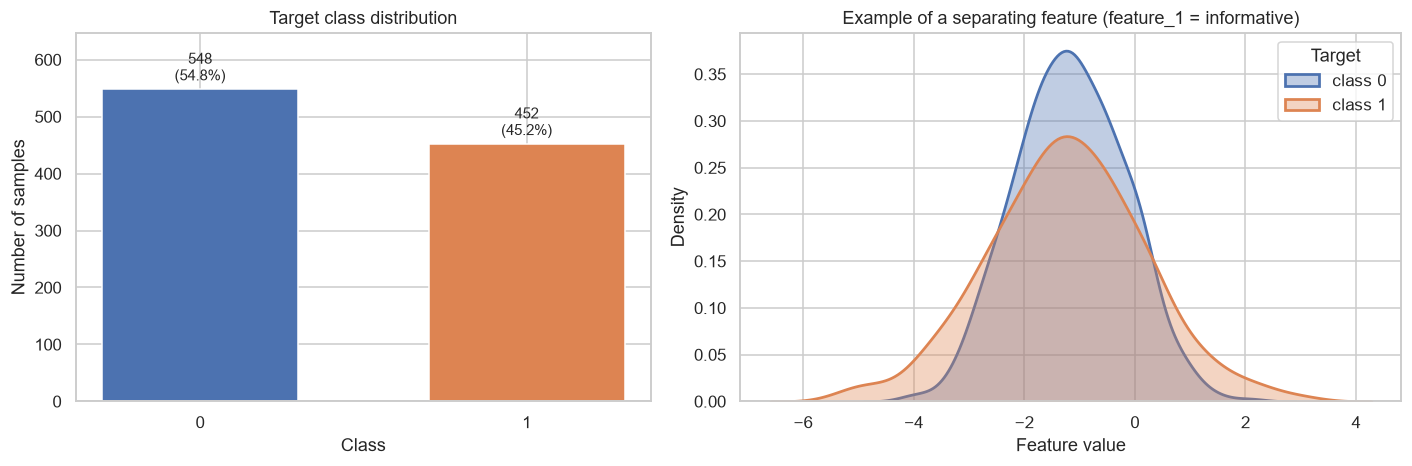

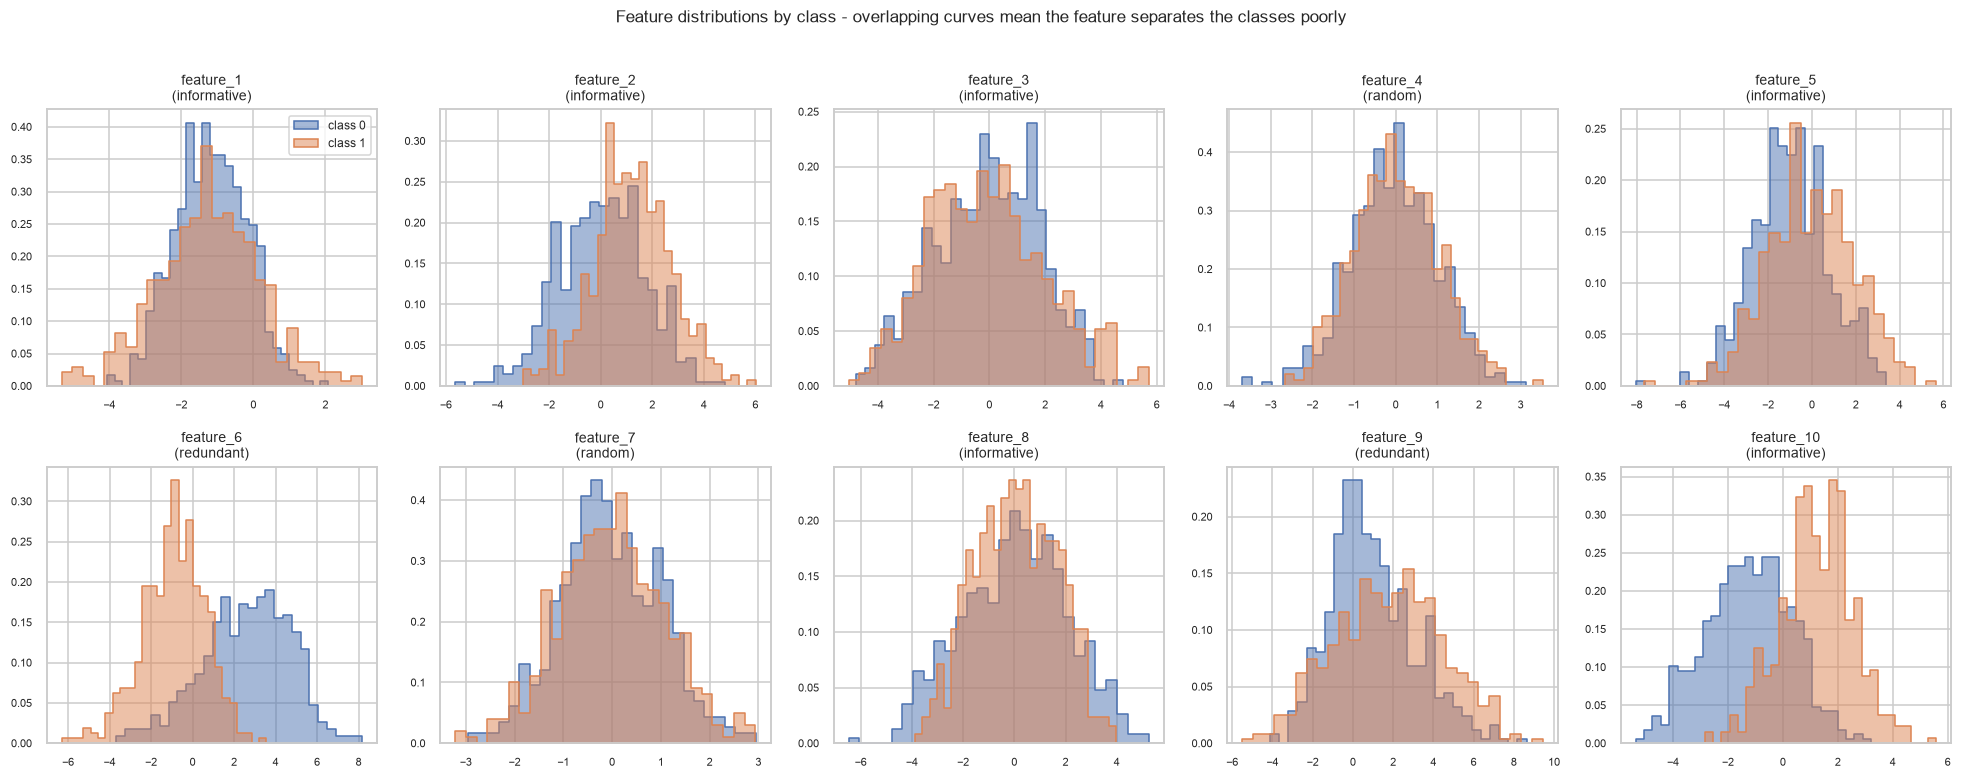

In [5]:
# ---------------------------------------------------------------------------
# Figure 1: class distribution (counts) and the distribution of each feature
# split by class. Features are annotated with the role recovered from the
# generator, so signal and noise columns can be told apart at a glance.
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.15]})

# --- Left panel: how many samples belong to each class? -------------------
class_counts = df["target"].value_counts().sort_index()
bars = axes[0].bar(class_counts.index.astype(str), class_counts.values,
                   color=["#4C72B0", "#DD8452"], width=0.6)
axes[0].set_title("Target class distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of samples")
axes[0].set_ylim(0, class_counts.max() * 1.18)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, count + 8,
                 f"{count}\n({count / len(df):.1%})", ha="center", va="bottom", fontsize=10)

# --- Right panel: how does each feature behave inside each class? ---------
for class_label, colour in zip([0, 1], ["#4C72B0", "#DD8452"]):
    subset = df.loc[df["target"] == class_label, "feature_1"]
    sns.kdeplot(subset, ax=axes[1], color=colour, fill=True, alpha=0.35,
                label=f"class {class_label}", linewidth=1.8)
axes[1].set_title(f"Example of a separating feature ({feature_names[0]} = {feature_roles[feature_names[0]]})")
axes[1].set_xlabel("Feature value")
axes[1].set_ylabel("Density")
axes[1].legend(title="Target")

plt.tight_layout()
plt.show()

# --- Feature-by-feature distributions -------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()
for ax, column in zip(axes, feature_names):
    for class_label, colour in zip([0, 1], ["#4C72B0", "#DD8452"]):
        sns.histplot(df.loc[df["target"] == class_label, column], bins=28, ax=ax,
                     color=colour, alpha=0.5, stat="density", element="step", fill=True,
                     label=f"class {class_label}")
    ax.set_title(f"{column}\n({feature_roles[column]})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=8)
fig.suptitle("Feature distributions by class - overlapping curves mean the feature separates the classes poorly",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

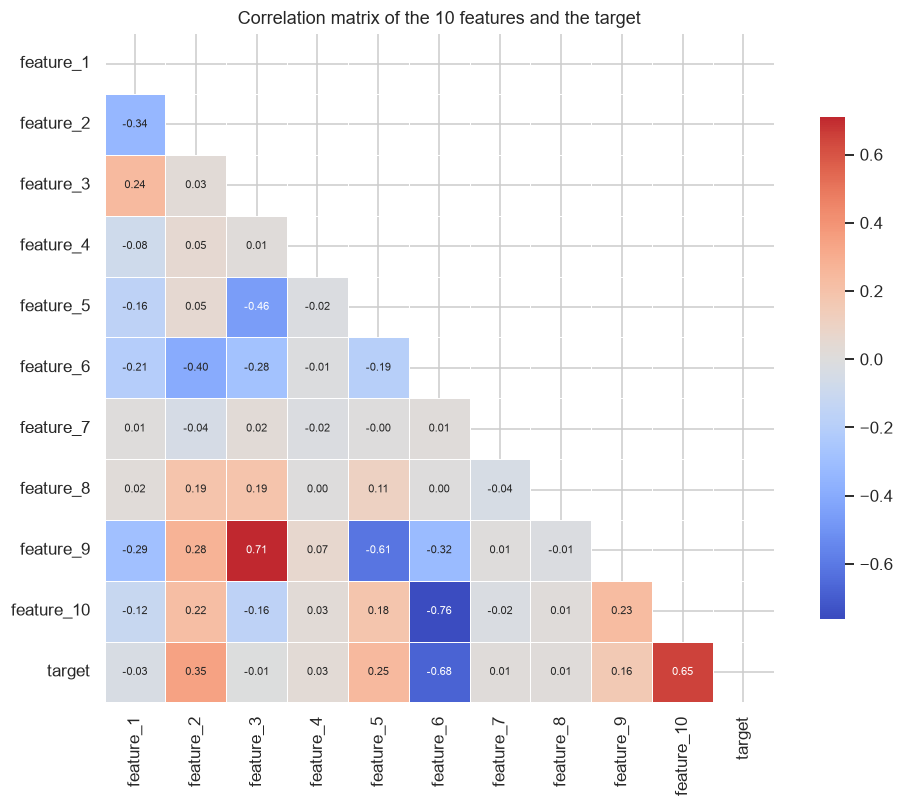

In [6]:
# ---------------------------------------------------------------------------
# Figure 2: correlation structure.
# Redundant features are linear combinations of informative features, so they
# are expected to show strong correlations. The target column is included to
# give a first idea of which features carry signal.
# ---------------------------------------------------------------------------

correlation_matrix = df.corr(numeric_only=True)
upper_triangle_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(
    correlation_matrix,
    mask=upper_triangle_mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.75},
)
plt.title("Correlation matrix of the 10 features and the target")
plt.tight_layout()
plt.show()

Feature signal strength (sorted by mutual information):


,Feature,Generator role,|Correlation with target|,Mutual information
0,feature_6,redundant,0.6796,0.3169
1,feature_10,informative,0.6501,0.2544
2,feature_2,informative,0.3473,0.0487
3,feature_5,informative,0.2484,0.0449
4,feature_1,informative,0.0326,0.0286
5,feature_3,informative,0.0078,0.0221
6,feature_8,informative,0.0129,0.0198
7,feature_9,redundant,0.1608,0.0190
8,feature_4,random,0.0342,0.0155
9,feature_7,random,0.0114,0.0087


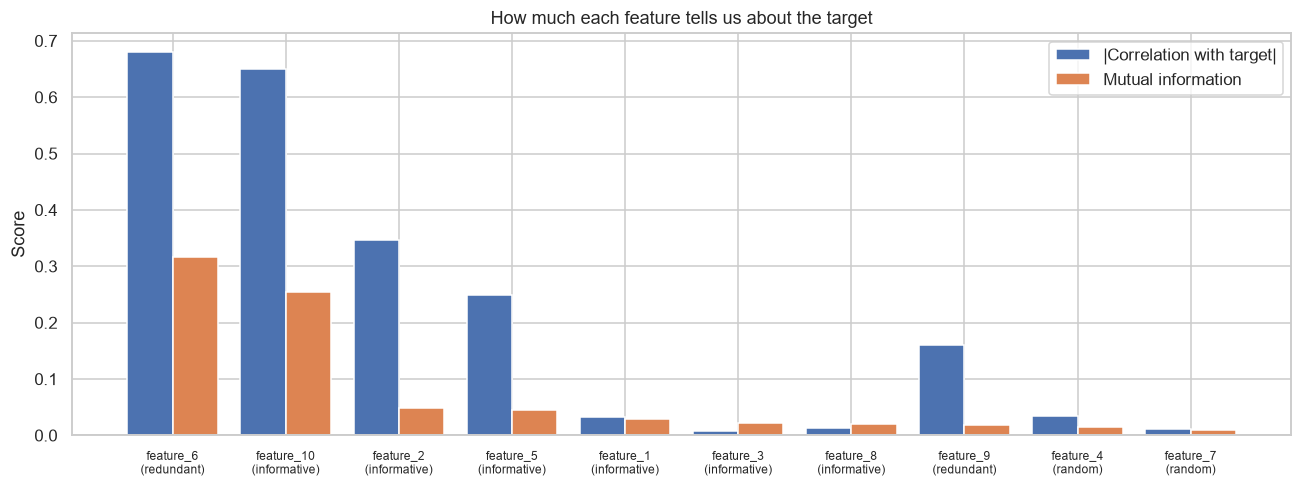

In [7]:
# ---------------------------------------------------------------------------
# Figure 3: quantify how much information each feature carries about the
# target, using two independent measures:
#   * |Pearson correlation| - linear association only.
#   * Mutual information    - any kind of dependence, linear or not.
# This is the evidence base for the "which features are noise" claim.
# ---------------------------------------------------------------------------

# Absolute Pearson correlation of every feature with the binary target.
absolute_correlation = np.abs(
    [np.corrcoef(df[column], df["target"])[0, 1] for column in feature_names]
)

# Mutual information between every feature and the target.
mutual_information = mutual_info_classif(X, y, random_state=RANDOM_STATE)

feature_signal_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Generator role": [feature_roles[column] for column in feature_names],
        "|Correlation with target|": absolute_correlation,
        "Mutual information": mutual_information,
    })
    .sort_values("Mutual information", ascending=False)
    .reset_index(drop=True)
)

print("Feature signal strength (sorted by mutual information):")
display(feature_signal_df.round(4))

# Plot the same information side by side.
plot_order = feature_signal_df["Feature"].tolist()
x_positions = np.arange(len(plot_order))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar(x_positions - bar_width / 2,
       feature_signal_df["|Correlation with target|"],
       bar_width, label="|Correlation with target|", color="#4C72B0")
ax.bar(x_positions + bar_width / 2,
       feature_signal_df["Mutual information"],
       bar_width, label="Mutual information", color="#DD8452")
ax.set_xticks(x_positions)
ax.set_xticklabels([f"{f}\n({r})" for f, r in zip(feature_signal_df["Feature"],
                                                  feature_signal_df["Generator role"])],
                   fontsize=8)
ax.set_ylabel("Score")
ax.set_title("How much each feature tells us about the target")
ax.legend()
plt.tight_layout()
plt.show()

### What the exploratory analysis shows

* **The classes are mildly imbalanced** (548 vs 452, roughly 55% / 45%). Accuracy alone is therefore
  slightly optimistic, and precision / recall / F1 are needed for a fair comparison.
* **The signal features separate the classes visibly**, but the class-conditional distributions
  still overlap substantially. Combined with `class_sep = 1.2` and the generator's 1% label noise,
  this means **no model can reach a perfect score**, and the remaining errors are genuinely
  ambiguous cases rather than implementation bugs.
* **The two `random` features show near-zero correlation and near-zero mutual information with the
  target**, exactly as the generator promises. They are noise by construction, and the plots confirm
  it empirically rather than assuming it.
* **The two `redundant` features are strongly correlated with some informative features** (they are
  linear combinations of them), which is visible in the correlation heatmap. This is important:
  correlated features split the importance between themselves, so coefficient- and
  importance-based interpretations must be read with care.
* **The features are on different scales** - the raw standard deviations range from
  1.039 to 2.561, a factor of about 2.5. That is not an extreme spread,
  but it is enough that an unscaled distance calculation would still be biased towards the
  higher-variance columns. Scaling is therefore applied for the distance- and margin-based models,
  as justified in the next section.

---
# 4. Data Preprocessing and Train-Test Split

## What preprocessing is needed, and why

| Step | Applied? | Justification |
|---|---|---|
| Missing-value imputation | **No** | The generator produces a complete array; the completeness check above reports zero missing values. |
| Categorical encoding | **No** | All 10 features are continuous numeric, and the target is already encoded as `0` / `1`. |
| Feature scaling (`StandardScaler`) | **Yes, for LR / SVM / KNN** | Logistic Regression converges better on standardised inputs, and SVM and KNN are *scale sensitive*: they rely on distances or on an RBF kernel whose width is measured in feature units. An unscaled feature with a large variance would dominate both. Random Forest is scale invariant (it only compares feature values with thresholds), so it is trained on the raw features. |
| Class-imbalance handling | **Yes** | `class_weight="balanced"` is used for Logistic Regression, Random Forest and SVM. It re-weights the loss inversely to class frequency, so mistakes on the minority class cost more. Note that KNN has no `class_weight` parameter, so the imbalance is left unaddressed for that model - the consequences are discussed in section 12. |
| Stratified splitting | **Yes** | `stratify=y` keeps the 55/45 class ratio identical in the training, validation and test sets, so no split accidentally becomes easier or harder than another. |

## Avoiding data leakage

This is the single most important rule in this section:

> The `StandardScaler` is fitted **only on `X_train`**. The validation and test sets are merely
> *transformed* with the already-fitted scaler.

Fitting the scaler on the full dataset (before splitting) would leak the mean and standard deviation
of the test set into training, and the reported test scores would be optimistic. The code below is
structured so that leakage is impossible by construction: `fit_transform` is called on the training
features only, and `transform` is used everywhere else.

## Splitting strategy

The starter notebook used a **70% / 15% / 15%** train / validation / test split, and that is
preserved here. It gives three distinct roles:

* **Training set (70%)** - used to fit the models.
* **Validation set (15%)** - used only for diagnostics (checking convergence, and the KNN
  sensitivity sweep in section 9). It never influences the final numbers.
* **Test set (15%)** - held back completely and used once, for the final comparison. **All four
  models are evaluated on this identical test set**, which is what makes the comparison fair.

In [8]:
# ---------------------------------------------------------------------------
# Split the dataset into 70% training, 15% validation and 15% test data.
# NOTE: this split is preserved from the original starter notebook.
# ---------------------------------------------------------------------------

# Separate input features from the target column.
X = df.drop("target", axis=1)

# Store the target column separately.
y = df["target"]

# First split the data into 70% training and 30% temporary data.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,                         # Input features.
    y,                         # Target labels.
    test_size=0.30,            # Keep 30% for validation and testing.
    random_state=RANDOM_STATE, # Use fixed random seed.
    stratify=y                 # Preserve class distribution in the split.
)

# Split the temporary 30% data equally into 15% validation and 15% test data.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,                    # Temporary input features.
    y_temp,                    # Temporary target labels.
    test_size=0.50,            # Half of 30% becomes test data.
    random_state=RANDOM_STATE, # Use fixed random seed.
    stratify=y_temp            # Preserve class distribution in validation and test sets.
)

# Print the number of rows in the training set.
print("Training set size:", X_train.shape[0])

# Print the number of rows in the validation set.
print("Validation set size:", X_val.shape[0])

# Print the number of rows in the test set.
print("Test set size:", X_test.shape[0])

# ---------------------------------------------------------------------------
# Verify that stratification preserved the class ratio in every split.
# ---------------------------------------------------------------------------
split_balance = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [len(y_train), len(y_val), len(y_test)],
    "Class 0 count": [int((y_train == 0).sum()), int((y_val == 0).sum()), int((y_test == 0).sum())],
    "Class 1 count": [int((y_train == 1).sum()), int((y_val == 1).sum()), int((y_test == 1).sum())],
})
split_balance["Class 1 share (%)"] = (
    100 * split_balance["Class 1 count"] / split_balance["Samples"]
).round(2)

print("\nClass balance per split (should be close to the overall 45.2%):")
display(split_balance)

# ---------------------------------------------------------------------------
# Feature scales: quantify the spread of standard deviations that motivates
# the scaling decision below. Computed on the training split only.
# ---------------------------------------------------------------------------
raw_feature_std = X_train.std()
print("Raw feature standard deviations on the training split:")
print(raw_feature_std.round(3).to_string())
print(f"\nSmallest standard deviation: {raw_feature_std.min():.3f} ({raw_feature_std.idxmin()})")
print(f"Largest standard deviation : {raw_feature_std.max():.3f} ({raw_feature_std.idxmax()})")
print(f"Ratio between them         : {raw_feature_std.max() / raw_feature_std.min():.2f}x")

Training set size: 700
Validation set size: 150
Test set size: 150

Class balance per split (should be close to the overall 45.2%):


,Split,Samples,Class 0 count,Class 1 count,Class 1 share (%)
0,Train,700,384,316,45.14
1,Validation,150,82,68,45.33
2,Test,150,82,68,45.33


Raw feature standard deviations on the training split:
feature_1     1.208
feature_2     1.678
feature_3     1.968
feature_4     1.047
feature_5     1.894
feature_6     2.561
feature_7     1.039
feature_8     1.884
feature_9     2.416
feature_10    1.889

Smallest standard deviation: 1.039 (feature_7)
Largest standard deviation : 2.561 (feature_6)
Ratio between them         : 2.47x


In [9]:
# ---------------------------------------------------------------------------
# Feature scaling.
# NOTE: the scaler is preserved from the original starter notebook, and the
#      fit/transform discipline is unchanged - it is fitted on the training
#      features ONLY, which prevents data leakage.
# ---------------------------------------------------------------------------

# Create a StandardScaler object.
scaler = StandardScaler()

# Fit the scaler only on the training features and transform the training features.
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation features using the scaler fitted on training data.
X_val_scaled = scaler.transform(X_val)

# Transform the test features using the scaler fitted on training data.
X_test_scaled = scaler.transform(X_test)

# Confirm that scaling worked: the training features should now be centred at
# ~0 with a standard deviation of ~1.
scaling_check = pd.DataFrame({
    "Feature": feature_names,
    "Mean after scaling": X_train_scaled.mean(axis=0),
    "Std after scaling": X_train_scaled.std(axis=0),
})
print("Scaler statistics (fitted on the training split only):")
display(scaling_check.round(4))

# ---------------------------------------------------------------------------
# Group the available feature representations so that each model can declare
# which one it needs. This keeps the training loop uniform and explicit.
# ---------------------------------------------------------------------------
FEATURE_SETS = {
    "raw":    {"train": X_train,        "val": X_val,        "test": X_test},
    "scaled": {"train": X_train_scaled, "val": X_val_scaled, "test": X_test_scaled},
}

print("\nFeature sets available for training:")
for set_name, splits in FEATURE_SETS.items():
    print(f"  {set_name:<7} -> train {splits['train'].shape}, "
          f"val {splits['val'].shape}, test {splits['test'].shape}")

Scaler statistics (fitted on the training split only):


,Feature,Mean after scaling,Std after scaling
0,feature_1,0.0,1.0
1,feature_2,0.0,1.0
2,feature_3,-0.0,1.0
3,feature_4,0.0,1.0
4,feature_5,0.0,1.0
5,feature_6,0.0,1.0
6,feature_7,0.0,1.0
7,feature_8,-0.0,1.0
8,feature_9,0.0,1.0
9,feature_10,-0.0,1.0



Feature sets available for training:
  raw     -> train (700, 10), val (150, 10), test (150, 10)
  scaled  -> train (700, 10), val (150, 10), test (150, 10)


---
# 5. Reusable Training and Evaluation Utilities

The assignment requires modular code with no unnecessary repetition. Everything that is done four
times over - fitting, predicting, and computing metrics - is therefore defined **once** here and
reused by all four models.

Three pieces of shared machinery are defined:

1. `train_and_predict(...)` - fits an estimator on the training split and stores every prediction
   and score it will ever need. Adding a fifth model later would require one line.
2. `calculate_metrics(...)` - the four headline metrics, in one place, so every model is scored
   identically.
3. `evaluate_model(...)` - the detailed per-model report (metrics, confusion matrix and
   classification report). This function is **preserved from the starter notebook**; it has only
   been extended with an explicit `zero_division=0` so it can never crash on an edge case.

Every model exposes a continuous score for ROC analysis: Logistic Regression, Random Forest and KNN
through `predict_proba`, and SVM through its `decision_function` margin (see the note in section 8).
Because ROC-AUC only depends on the *ranking* of those scores, the four models remain directly
comparable.

Because every model is scored by the same function on the same `y_test`, the comparison in section
11 is guaranteed to be methodologically consistent.

In [10]:
# ---------------------------------------------------------------------------
# Shared registry of trained models and reusable training/evaluation helpers.
# ---------------------------------------------------------------------------

# Human-readable names, used in every table and plot.
MODEL_DISPLAY_NAMES = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
    "svm": "SVM",
    "knn": "KNN",
}

# Every trained model's artefacts are stored here, keyed by the short model key.
MODELS = {}


def positive_class_scores(estimator, features):
    """Return a continuous score for the positive class, used for ROC analysis.

    `predict_proba` is preferred; `decision_function` is the fallback for any
    estimator that does not expose probabilities.
    """
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(features)[:, 1]
    return estimator.decision_function(features)


def train_and_predict(model_key, estimator, feature_set_name):
    """Fit `estimator` on the training split and store all predictions it needs.

    Parameters
    ----------
    model_key : str
        Short key from MODEL_DISPLAY_NAMES, used to store the results.
    estimator : sklearn estimator
        An *unfitted* classifier instance.
    feature_set_name : {"raw", "scaled"}
        Which representation from FEATURE_SETS this model should be trained on.

    Returns
    -------
    dict
        The stored artefacts: estimator, hyperparameters and predictions for
        the training, validation and test splits.
    """
    features = FEATURE_SETS[feature_set_name]

    # Fit on the training split only - never on validation or test data.
    estimator.fit(features["train"], y_train)

    MODELS[model_key] = {
        "name": MODEL_DISPLAY_NAMES[model_key],
        "estimator": estimator,
        "feature_set": feature_set_name,
        "hyperparameters": estimator.get_params(),
        "train_predictions": estimator.predict(features["train"]),
        "val_predictions": estimator.predict(features["val"]),
        "test_predictions": estimator.predict(features["test"]),
        "test_scores": positive_class_scores(estimator, features["test"]),
    }

    print(f"Trained {MODEL_DISPLAY_NAMES[model_key]:<18} "
          f"({type(estimator).__name__:<26}) on the '{feature_set_name}' feature set.")
    return MODELS[model_key]


def calculate_metrics(y_true, y_pred):
    """Return Accuracy, Precision, Recall and F1-score in a single dictionary."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }


def confusion_counts(y_true, y_pred):
    """Return the four confusion-matrix cells, explicitly labelled.

    The matrix is requested with labels=[0, 1] so the order of the cells can
    never silently flip.
    """
    true_negatives, false_positives, false_negatives, true_positives = (
        confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    )
    return {
        "True Negatives": int(true_negatives),
        "False Positives": int(false_positives),
        "False Negatives": int(false_negatives),
        "True Positives": int(true_positives),
    }


def evaluate_model(model_name, y_true, y_pred):
    """Print a complete evaluation report for one model.

    Preserved from the starter notebook, with `zero_division=0` added so that a
    degenerate prediction can never raise a warning or an error.
    """
    # Print the model name.
    print(f"\nModel: {model_name}")

    # Print the accuracy score.
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))

    # Print the precision score.
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))

    # Print the recall score.
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0), 4))

    # Print the F1-score.
    print("F1-score:", round(f1_score(y_true, y_pred, zero_division=0), 4))

    # Print the confusion matrix.
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred, labels=[0, 1]))

    # Print the full classification report.
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))


def metrics_table(split_name):
    """Build a Model x metric table for one split ("train", "val" or "test")."""
    rows = []
    for model_key, artefacts in MODELS.items():
        # Map the short split name to the stored prediction key.
        prediction_key = {"train": "train_predictions",
                          "val": "val_predictions",
                          "test": "test_predictions"}[split_name]
        y_true = {"train": y_train, "val": y_val, "test": y_test}[split_name]

        row = {"Model": artefacts["name"]}
        row.update(calculate_metrics(y_true, artefacts[prediction_key]))
        rows.append(row)
    return pd.DataFrame(rows)


def show_hyperparameters():
    """Print the important hyperparameters of every registered model."""
    for model_key, artefacts in MODELS.items():
        params = artefacts["hyperparameters"]
        print(f"\n{artefacts['name']}  ({type(artefacts['estimator']).__name__})"
              f"  - trained on the '{artefacts['feature_set']}' feature set")
        for parameter_name, value in params.items():
            # Skip parameters that are irrelevant noise for the reader.
            if parameter_name in {"verbose", "warm_start"}:
                continue
            # scikit-learn 1.9 marks phased-out parameters with the sentinel
            # string "deprecated" (e.g. LogisticRegression.penalty and
            # SVC.probability). Printing that literal value would only confuse,
            # so those rows are omitted - the notebook does not set them.
            if value == "deprecated":
                continue
            print(f"    {parameter_name:<28} = {value}")


print("Reusable training and evaluation utilities are ready.")

Reusable training and evaluation utilities are ready.


---
# 6. Model 1 - Logistic Regression

## The idea behind the model

Logistic Regression is a **linear** classifier. It computes a weighted sum of the input features and
squashes it through the logistic (sigmoid) function to produce a probability between 0 and 1:

$$P(y = 1 \mid x) = \frac{1}{1 + e^{-(w^\top x + b)}}$$

A sample is assigned to class 1 when that probability exceeds 0.5, which means the decision boundary
is a **single straight hyperplane**. This is exactly what the starter notebook described, and it is
both the model's strength and its limitation here:

* **Strength** - with only 700 training samples and 10 features, a linear model has very few
  parameters, so it is hard to overfit. On a dataset whose classes are generated as Gaussian blobs,
  a linear boundary is often close to optimal.
* **Limitation** - if the true boundary is curved, no choice of weights can capture it.

## Important hyperparameters used

| Hyperparameter | Value | Why this value |
|---|---|---|
| `solver` | `lbfgs` (default) | A robust quasi-Newton solver that works well on standardised features of this size. |
| `max_iter` | `1000` | The default of 100 raises convergence warnings on this data; 1000 iterations lets the solver converge cleanly. |
| `C` | `1.0` (default) | Inverse regularisation strength. `1.0` is the standard, mildly regularised setting. |
| `class_weight` | `"balanced"` | Re-weights the loss inversely to class frequency so the 45% minority class is not ignored. |
| `random_state` | `42` | Reproducibility. |

Because the model is linear, it is trained on the **scaled** feature set - the solver converges more
reliably and the regularisation penalty is applied evenly across features.

In [11]:
# ---------------------------------------------------------------------------
# Model 1: Logistic Regression
# ---------------------------------------------------------------------------
logistic_regression = LogisticRegression(
    solver="lbfgs",              # Quasi-Newton solver, well suited to standardised features.
    C=1.0,                       # Mild L2 regularisation.
    max_iter=1000,               # Allow enough iterations for convergence.
    random_state=RANDOM_STATE,   # Use fixed random seed.
    class_weight="balanced",     # Handle the mild class imbalance.
)

# Train the model and collect its predictions through the shared helper.
train_and_predict("logistic_regression", logistic_regression, feature_set_name="scaled")

Trained Logistic Regression (LogisticRegression        ) on the 'scaled' feature set.


{'name': 'Logistic Regression',
 'estimator': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'feature_set': 'scaled',
 'hyperparameters': {'C': 1.0,
  'class_weight': 'balanced',
  'dual': False,
  'fit_intercept': True,
  'intercept_scaling': 1,
  'l1_ratio': 0.0,
  'max_iter': 1000,
  'n_jobs': None,
  'penalty': 'deprecated',
  'random_state': 42,
  'solver': 'lbfgs',
  'tol': 0.0001,
  'verbose': 0,
  'warm_start': False},
 'train_predictions': array([1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
        0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,

---
# 7. Model 2 - Random Forest Classifier

## The idea behind the model

A Random Forest is a **bagged ensemble of decision trees**, and it was already the second model in
the starter notebook:

* each tree is trained on a bootstrap sample of the training data,
* at every split, only a random subset of the features is considered,
* the final prediction is decided by majority vote across all trees.

Averaging many decorrelated trees cancels out a large part of the variance that a single tree would
have, which is why Random Forest overfits far less than one deep decision tree. Its decision
boundary is **piecewise constant and axis-aligned** - a staircase built from `feature_j <= threshold`
tests.

## Important hyperparameters used

| Hyperparameter | Value | Why this value |
|---|---|---|
| `n_estimators` | `100` | 100 trees give a stable vote without excessive runtime; the default in the starter notebook. |
| `max_depth` | `None` | Trees grow until the leaves are pure. This maximises fit and, as the generalisation gap in section 10 will show, does allow some overfitting. |
| `max_features` | `"sqrt"` (default) | Each split sees only `sqrt(10) ~ 3` candidate features, which decorrelates the trees. |
| `bootstrap` | `True` (default) | Bagging is the mechanism that reduces variance. |
| `class_weight` | `"balanced"` | Same imbalance handling as Logistic Regression. |
| `random_state` | `42` | Reproducibility. |

A Random Forest compares feature values against thresholds, so it is **invariant to any monotonic
rescaling** of a feature. It is therefore trained on the **raw** feature set - applying
`StandardScaler` would change nothing but the runtime.

In [12]:
# ---------------------------------------------------------------------------
# Model 2: Random Forest Classifier
# NOTE: hyperparameters are preserved from the original starter notebook.
# ---------------------------------------------------------------------------
random_forest = RandomForestClassifier(
    n_estimators=100,            # Use 100 decision trees.
    max_depth=None,              # Allow trees to grow until stopping criteria are met.
    max_features="sqrt",         # Consider sqrt(n_features) candidates at each split.
    random_state=RANDOM_STATE,   # Use fixed random seed.
    class_weight="balanced",     # Handle possible class imbalance.
)

# Train the model on the raw (unscaled) features - trees do not need scaling.
train_and_predict("random_forest", random_forest, feature_set_name="raw")

Trained Random Forest      (RandomForestClassifier    ) on the 'raw' feature set.


{'name': 'Random Forest',
 'estimator': RandomForestClassifier(class_weight='balanced', random_state=42),
 'feature_set': 'raw',
 'hyperparameters': {'bootstrap': True,
  'ccp_alpha': 0.0,
  'class_weight': 'balanced',
  'criterion': 'gini',
  'max_depth': None,
  'max_features': 'sqrt',
  'max_leaf_nodes': None,
  'max_samples': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'monotonic_cst': None,
  'n_estimators': 100,
  'n_jobs': None,
  'oob_score': False,
  'random_state': 42,
  'verbose': 0,
  'warm_start': False},
 'train_predictions': array([1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
   

---
# 8. Model 3 - Support Vector Machine (SVM, RBF kernel)

## The idea behind the model

A Support Vector Machine searches for the decision boundary that leaves the **widest possible margin**
between the two classes, penalising samples that fall on the wrong side or inside the margin. With a
**radial basis function (RBF) kernel** it implicitly maps the data into a much higher-dimensional
space, where a linear separator corresponds to a **smooth, non-linear boundary** in the original
feature space.

The RBF kernel measures similarity as $K(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$. Two
consequences follow directly, and both are relevant to this dataset:

1. It is built on **Euclidean distances**, so the model is **scale sensitive**. Training it on
   unscaled features - where the standard deviations range from 1.039 to
   2.561 - would let the higher-variance columns dominate the kernel. Scaling is
   applied, and it is done correctly (fitted on the training split only).
2. It is **not** a linear model, so it can capture curvature that Logistic Regression cannot.

## Important hyperparameters used

| Hyperparameter | Value | Why this value |
|---|---|---|
| `kernel` | `"rbf"` | Enables a non-linear boundary without manually engineering features. |
| `C` | `1.0` | The margin/error trade-off. Small `C` gives a wide, soft margin; large `C` punishes errors hard and risks overfitting. `1.0` is the standard balanced starting point. |
| `gamma` | `"scale"` | Sets $\gamma = 1 / (n_{features} \cdot \mathrm{Var}(X))$. This adapts the kernel width to the data instead of hard-coding it. |
| `class_weight` | `"balanced"` | Same imbalance handling as the other models. |
| `random_state` | `42` | Keeps the fit deterministic. |

**A note on probabilities.** `SVC(probability=True)` - which forces the model to calibrate
probabilities through an internal cross-validated Platt scaling - is deprecated as of
scikit-learn 1.9 (removal planned for 1.11). It is therefore **not** used here. The SVM is fitted
without it, and its ROC curve is built from the `decision_function` margin instead. That is not a
compromise: ROC-AUC depends only on how well a model *ranks* samples, and the margin is a perfectly
valid monotone ranking score. The only consequence is that the SVM's "score for class 1" column in
the prediction tables is a signed margin (roughly -3 to +3) rather than a probability in [0, 1].

Trained on the **scaled** feature set, as required by the kernel's distance computation.

In [13]:
# ---------------------------------------------------------------------------
# Model 3: Support Vector Machine with an RBF kernel.
# ---------------------------------------------------------------------------
support_vector_machine = SVC(
    kernel="rbf",                # Non-linear radial basis function kernel.
    C=1.0,                       # Margin / error trade-off.
    gamma="scale",               # Kernel width adapted to the data.
    random_state=RANDOM_STATE,   # Keeps the fit deterministic.
    class_weight="balanced",     # Handle the mild class imbalance.
)

# Train on the scaled features - the RBF kernel is distance based.
train_and_predict("svm", support_vector_machine, feature_set_name="scaled")

Trained SVM                (SVC                       ) on the 'scaled' feature set.


{'name': 'SVM',
 'estimator': SVC(class_weight='balanced', random_state=42),
 'feature_set': 'scaled',
 'hyperparameters': {'C': 1.0,
  'break_ties': False,
  'cache_size': 200,
  'class_weight': 'balanced',
  'coef0': 0.0,
  'decision_function_shape': 'ovr',
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'rbf',
  'max_iter': -1,
  'probability': 'deprecated',
  'random_state': 42,
  'shrinking': True,
  'tol': 0.001,
  'verbose': False},
 'train_predictions': array([1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
        1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
        0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 1

---
# 9. Model 4 - K-Nearest Neighbors (KNN)

## The idea behind the model

K-Nearest Neighbors is the simplest non-parametric classifier: to label a new point it finds the `k`
closest training points and takes a majority vote. There is no training phase at all - the entire
training set *is* the model - and the decision boundary is implicitly defined by the local
neighbourhoods, which makes it highly flexible but also highly sensitive to the data.

Three properties matter a great deal for this particular dataset:

1. **It is purely distance based**, so it is scale sensitive and must be trained on scaled features.
2. **It suffers in higher dimensions.** With 10 features, and 2 of them pure noise, every distance
   is inflated by noise that carries no class information. This dilutes the neighbourhood: genuine
   neighbours become harder to distinguish from random ones. This is the curse of dimensionality.
   Section 11.3 tests how large that effect actually is on this dataset rather than assuming it is
   large - and the honest answer is that it turns out to be mild at 10 dimensions.
3. **It has no `class_weight` parameter.** Unlike the other three models, KNN cannot be told to
   penalise minority-class errors more heavily. With a 55/45 split, its majority vote will therefore
   lean slightly towards the majority class, which is visible in its precision/recall balance.

## Important hyperparameters used

| Hyperparameter | Value | Why this value |
|---|---|---|
| `n_neighbors` (`k`) | `5` | The standard starting point: large enough to smooth out single-point noise, small enough to keep the boundary local. A sensitivity sweep over `k` is run below to show how much this choice matters. |
| `weights` | `"uniform"` | Every neighbour in the neighbourhood votes equally, so the effect of `k` is easy to interpret. |
| `metric` | `"minkowski"` with `p=2` (default) | Euclidean distance. |
| `n_jobs` | `-1` | Uses all available cores; has no effect on the result. |

Trained on the **scaled** feature set.

In [14]:
# ---------------------------------------------------------------------------
# Model 4: K-Nearest Neighbors.
# ---------------------------------------------------------------------------
k_nearest_neighbors = KNeighborsClassifier(
    n_neighbors=5,               # k = 5 neighbours vote on each prediction.
    weights="uniform",           # Equal vote for every neighbour.
    metric="minkowski",          # Minkowski distance ...
    p=2,                         # ... with p = 2, i.e. Euclidean distance.
    n_jobs=-1,                   # Use all available cores.
)

# Train on the scaled features - KNN is purely distance based.
train_and_predict("knn", k_nearest_neighbors, feature_set_name="scaled")

Trained KNN                (KNeighborsClassifier      ) on the 'scaled' feature set.


{'name': 'KNN',
 'estimator': KNeighborsClassifier(n_jobs=-1),
 'feature_set': 'scaled',
 'hyperparameters': {'algorithm': 'auto',
  'leaf_size': 30,
  'metric': 'minkowski',
  'metric_params': None,
  'n_jobs': -1,
  'n_neighbors': 5,
  'p': 2,
  'weights': 'uniform'},
 'train_predictions': array([1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
        0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
        0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0

KNN sensitivity to k (validation set):
 k (n_neighbors)  Validation Accuracy
               1               0.9467
               3               0.9400
               5               0.9533
               7               0.9533
               9               0.9467
              11               0.9533
              13               0.9667
              15               0.9800
              17               0.9800
              19               0.9533
              21               0.9467
              23               0.9400
              25               0.9667

Best k on the validation set: 15 (validation accuracy 0.9800); the submitted model uses k=5.


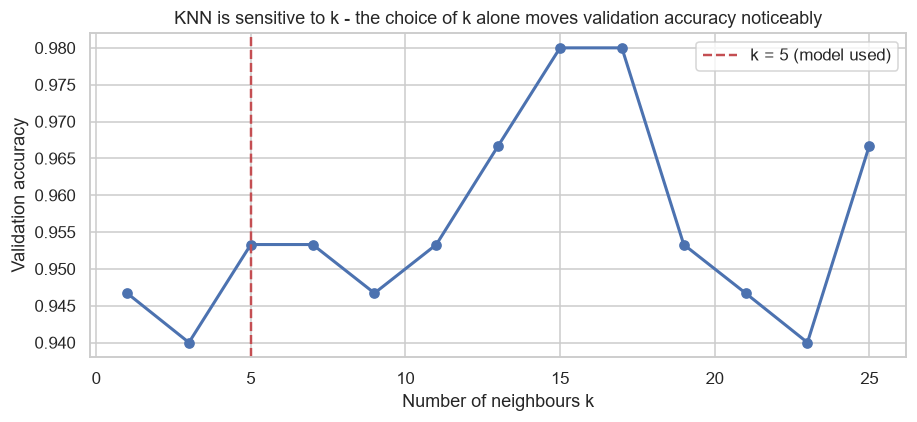

In [15]:
# ---------------------------------------------------------------------------
# KNN sensitivity to k (diagnostic only, evaluated on the VALIDATION set).
# This is not used to tune the final model - it exists to show how strongly
# KNN depends on a single hyperparameter, which is discussed in section 12.
# ---------------------------------------------------------------------------
k_values = list(range(1, 26, 2))
knn_validation_accuracy = []

for k in k_values:
    candidate = KNeighborsClassifier(n_neighbors=k, weights="uniform", n_jobs=-1)
    candidate.fit(X_train_scaled, y_train)
    knn_validation_accuracy.append(accuracy_score(y_val, candidate.predict(X_val_scaled)))

knn_sweep_df = pd.DataFrame({
    "k (n_neighbors)": k_values,
    "Validation Accuracy": np.round(knn_validation_accuracy, 4),
})
print("KNN sensitivity to k (validation set):")
print(knn_sweep_df.to_string(index=False))

best_k_row = knn_sweep_df.loc[knn_sweep_df["Validation Accuracy"].idxmax()]
print(f"\nBest k on the validation set: {int(best_k_row['k (n_neighbors)'])} "
      f"(validation accuracy {best_k_row['Validation Accuracy']:.4f}); "
      f"the submitted model uses k=5.")

# Visualise the sweep.
plt.figure(figsize=(8.5, 4))
plt.plot(knn_sweep_df["k (n_neighbors)"], knn_sweep_df["Validation Accuracy"],
         marker="o", color="#4C72B0", linewidth=2)
plt.axvline(5, color="#C44E52", linestyle="--", linewidth=1.6, label="k = 5 (model used)")
plt.xlabel("Number of neighbours k")
plt.ylabel("Validation accuracy")
plt.title("KNN is sensitive to k - the choice of k alone moves validation accuracy noticeably")
plt.legend()
plt.tight_layout()
plt.show()

---
# 10. Evaluation Results

All four models are now trained. This section evaluates them with **one consistent methodology**:

* every model is scored on the **same `y_test`**,
* every metric comes from the same `calculate_metrics(...)` function,
* every confusion matrix is built with an explicit `labels=[0, 1]` so the cells cannot be silently
  transposed.

The evaluation is organised in five parts:

1. **Generalisation check** - training vs validation vs test accuracy, to expose overfitting.
2. **Detailed per-model reports** - accuracy, precision, recall, F1, confusion matrix and
   classification report for each model.
3. **Confusion matrices** as heatmaps.
4. **ROC curves and ROC-AUC.**
5. **Prediction tables**, plus a single-sample demonstration.

Before the metrics themselves: the hyperparameters below are read back from the fitted estimators
rather than restated from memory, so what is documented here is exactly what was trained.

In [16]:
# ---------------------------------------------------------------------------
# Read the hyperparameters back off every fitted estimator. This is the
# authoritative record of what each model was actually trained with.
# ---------------------------------------------------------------------------
show_hyperparameters()


Logistic Regression  (LogisticRegression)  - trained on the 'scaled' feature set
    C                            = 1.0
    class_weight                 = balanced
    dual                         = False
    fit_intercept                = True
    intercept_scaling            = 1
    l1_ratio                     = 0.0
    max_iter                     = 1000
    n_jobs                       = None
    random_state                 = 42
    solver                       = lbfgs
    tol                          = 0.0001

Random Forest  (RandomForestClassifier)  - trained on the 'raw' feature set
    bootstrap                    = True
    ccp_alpha                    = 0.0
    class_weight                 = balanced
    criterion                    = gini
    max_depth                    = None
    max_features                 = sqrt
    max_leaf_nodes               = None
    max_samples                  = None
    min_impurity_decrease        = 0.0
    min_samples_leaf             = 1
 

## 10.1 Generalisation check (overfitting)

A model that memorises its training data scores near-perfectly on the training set and much worse on
held-out data. Comparing the three splits makes that visible: the **generalisation gap** is
`train accuracy - test accuracy`. A small gap means the model generalises; a large gap means it has
learned the training noise.

Accuracy across splits (gap = train accuracy - test accuracy):
              Model  Train Accuracy  Validation Accuracy  Test Accuracy  Generalisation Gap
      Random Forest          1.0000               0.9400         0.9333              0.0667
                SVM          0.9500               0.9533         0.9333              0.0167
                KNN          0.9657               0.9533         0.9333              0.0324
Logistic Regression          0.8543               0.8600         0.8600             -0.0057


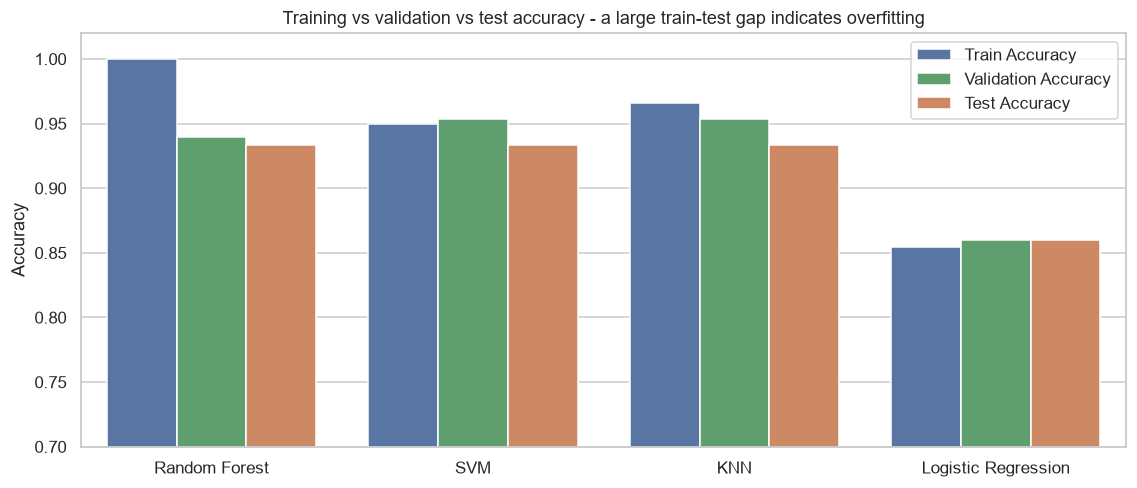

In [17]:
# ---------------------------------------------------------------------------
# Training vs validation vs test accuracy for every model, built from the
# reusable metrics_table() helper so the scoring code is written only once.
# ---------------------------------------------------------------------------
train_accuracy_by_model = metrics_table("train").set_index("Model")["Accuracy"]
val_accuracy_by_model = metrics_table("val").set_index("Model")["Accuracy"]
test_accuracy_by_model = metrics_table("test").set_index("Model")["Accuracy"]

# Assemble the three splits side by side, keeping a single consistent row order.
generalisation_df = pd.DataFrame({
    "Model": test_accuracy_by_model.index,
    "Train Accuracy": train_accuracy_by_model.values,
    "Validation Accuracy": val_accuracy_by_model.loc[test_accuracy_by_model.index].values,
    "Test Accuracy": test_accuracy_by_model.values,
})
generalisation_df["Generalisation Gap"] = (
    generalisation_df["Train Accuracy"] - generalisation_df["Test Accuracy"]
)
generalisation_df = generalisation_df.sort_values(
    "Test Accuracy", ascending=False
).reset_index(drop=True)

print("Accuracy across splits (gap = train accuracy - test accuracy):")
print(generalisation_df.round(4).to_string(index=False))

# Visualise the three splits side by side.
split_plot_df = generalisation_df.melt(
    id_vars="Model",
    value_vars=["Train Accuracy", "Validation Accuracy", "Test Accuracy"],
    var_name="Split", value_name="Accuracy",
)
plt.figure(figsize=(10.5, 4.6))
sns.barplot(data=split_plot_df, x="Model", y="Accuracy", hue="Split",
            palette=["#4C72B0", "#55A868", "#DD8452"])
plt.ylim(0.7, 1.02)
plt.title("Training vs validation vs test accuracy - a large train-test gap indicates overfitting")
plt.xlabel("")
plt.ylabel("Accuracy")
plt.legend(title="")
plt.tight_layout()
plt.show()

## 10.2 Detailed evaluation of every model on the test set

The report below is produced by the preserved `evaluate_model(...)` function, called once per model on
the **same test set**.

In [18]:
# ---------------------------------------------------------------------------
# Full per-model report on the test set: metrics, confusion matrix and
# classification report. Produced by the preserved evaluate_model() helper.
# ---------------------------------------------------------------------------
for model_key, artefacts in MODELS.items():
    evaluate_model(artefacts["name"] + " - Test Set",
                   y_test, artefacts["test_predictions"])


Model: Logistic Regression - Test Set
Accuracy: 0.86
Precision: 0.8133
Recall: 0.8971
F1-score: 0.8531

Confusion Matrix:
[[68 14]
 [ 7 61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.81      0.90      0.85        68

    accuracy                           0.86       150
   macro avg       0.86      0.86      0.86       150
weighted avg       0.86      0.86      0.86       150


Model: Random Forest - Test Set
Accuracy: 0.9333
Precision: 0.9028
Recall: 0.9559
F1-score: 0.9286

Confusion Matrix:
[[75  7]
 [ 3 65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94        82
           1       0.90      0.96      0.93        68

    accuracy                           0.93       150
   macro avg       0.93      0.94      0.93       150
weighted avg       0.93      0.93      0.93       150


Model: SVM - Test

## 10.3 Confusion matrices

Each confusion matrix is read as:

|  | Predicted class 0 | Predicted class 1 |
|---|---|---|
| **Actual class 0** | True Negative (TN) | **False Positive (FP)** |
| **Actual class 1** | **False Negative (FN)** | True Positive (TP) |

* A **false positive** means a negative sample was flagged as positive - a *false alarm*.
* A **false negative** means a positive sample was missed - a *missed detection*.

Which of the two matters more is a decision about the problem, not about the algorithm. Reporting both
separately (rather than hiding them behind accuracy) is what makes the comparison in section 11
possible.

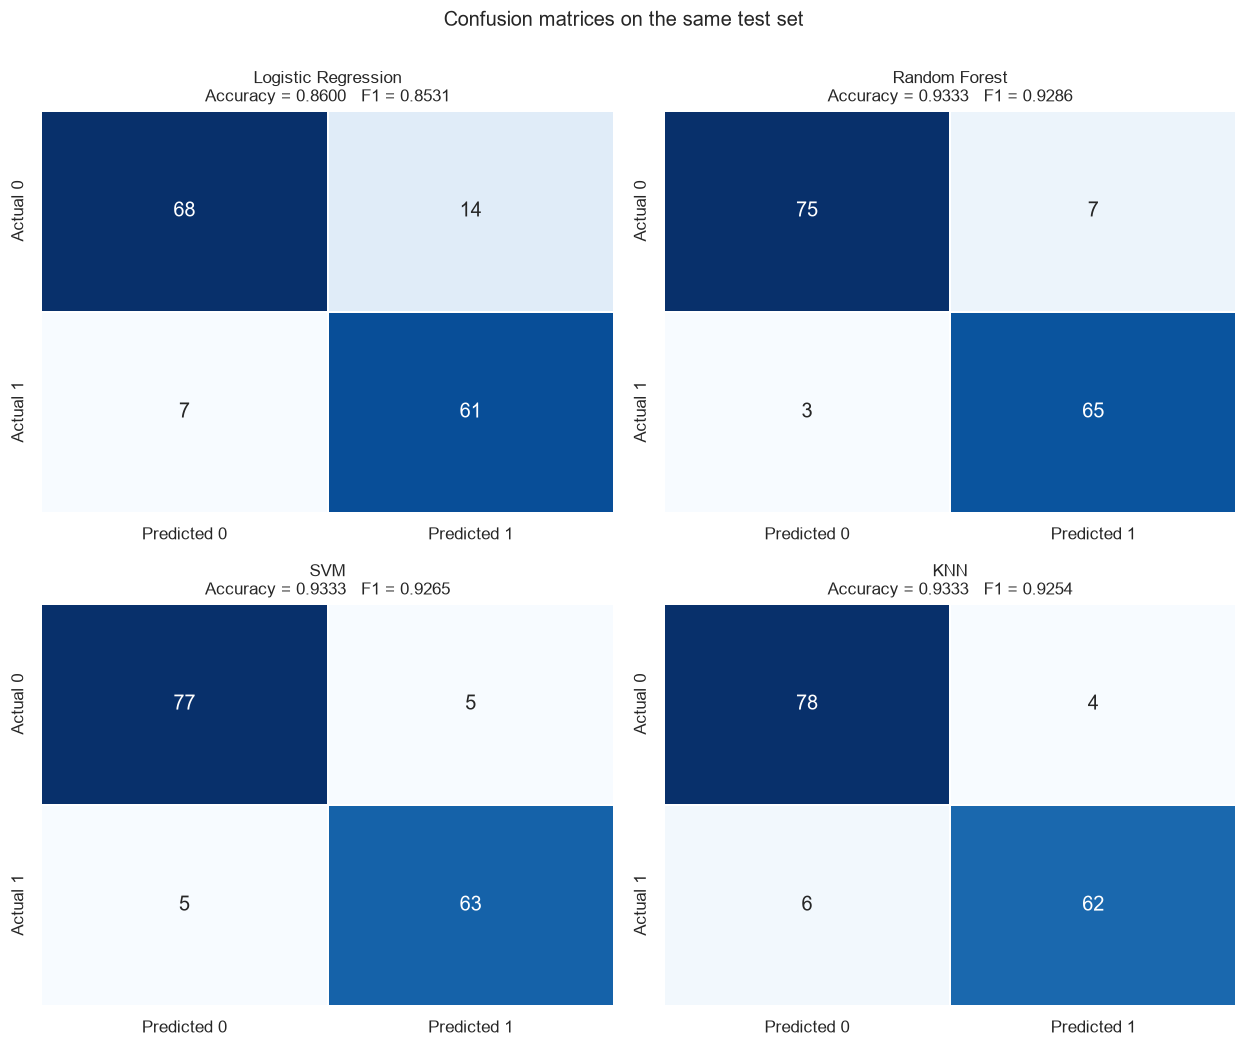

In [19]:
# ---------------------------------------------------------------------------
# Confusion matrices for all four models, drawn as heatmaps.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.5))
axes = axes.ravel()

for ax, (model_key, artefacts) in zip(axes, MODELS.items()):
    matrix = confusion_matrix(y_test, artefacts["test_predictions"], labels=[0, 1])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                linewidths=1, linecolor="white", annot_kws={"size": 13},
                xticklabels=["Predicted 0", "Predicted 1"],
                yticklabels=["Actual 0", "Actual 1"])
    accuracy = accuracy_score(y_test, artefacts["test_predictions"])
    f1 = f1_score(y_test, artefacts["test_predictions"], zero_division=0)
    ax.set_title(f"{artefacts['name']}\nAccuracy = {accuracy:.4f}   F1 = {f1:.4f}", fontsize=11)

fig.suptitle("Confusion matrices on the same test set", y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

## 10.4 ROC curves and ROC-AUC

Accuracy depends on a single decision threshold (0.5). The ROC curve sweeps the threshold across its
entire range and plots the true-positive rate against the false-positive rate, and the area under that
curve (**ROC-AUC**) summarises ranking quality independently of any threshold. It is a useful
complement here because it shows how well each model *separates* the classes, not merely where it
happens to place the cut-off.

Logistic Regression, Random Forest and KNN are scored using `predict_proba`. The SVM has no calibrated
probability (see the note in section 8), so it is scored using its `decision_function` margin. Because
ROC-AUC depends only on the ranking of scores, not on their absolute scale, all four models remain
directly comparable.

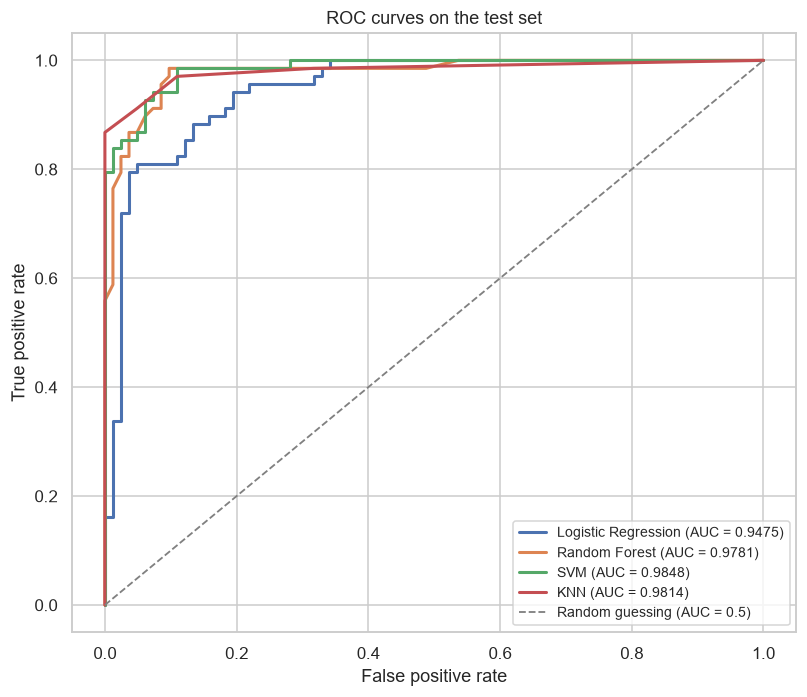

ROC-AUC on the test set:
              Model  ROC-AUC
                SVM   0.9848
                KNN   0.9814
      Random Forest   0.9781
Logistic Regression   0.9475


In [20]:
# ---------------------------------------------------------------------------
# ROC curves and ROC-AUC for all four models on the test set.
# Scores come from predict_proba where available and from the SVM margin
# otherwise - both are valid monotone ranking scores for ROC-AUC.
# ---------------------------------------------------------------------------
plt.figure(figsize=(7.5, 6.5))
roc_rows = []

for model_key, artefacts in MODELS.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, artefacts["test_scores"])
    area_under_curve = roc_auc_score(y_test, artefacts["test_scores"])
    roc_rows.append({"Model": artefacts["name"], "ROC-AUC": area_under_curve})
    plt.plot(false_positive_rate, true_positive_rate, linewidth=2,
             label=f"{artefacts['name']} (AUC = {area_under_curve:.4f})")

# The diagonal represents a classifier that guesses at random.
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1.2, label="Random guessing (AUC = 0.5)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on the test set")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

roc_auc_df = pd.DataFrame(roc_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("ROC-AUC on the test set:")
print(roc_auc_df.round(4).to_string(index=False))

## 10.5 Prediction tables and a single-sample demonstration

Finally, the test-set predictions are collected into readable tables - one row per test sample, with
the true label, the predicted label, the model's score for class 1, and a flag marking whether the
prediction was correct. These tables make it easy to inspect individual errors rather than only
aggregate scores.

The score column is a probability for Logistic Regression, Random Forest and KNN, and a signed margin
for the SVM. That distinction is stated in the column name so the tables cannot be misread.

The starter notebook's "predict a new sample" demonstration is preserved at the end of this section,
generalised to all four models.

In [21]:
# ---------------------------------------------------------------------------
# One prediction table per model: true label, predicted label, score for class
# 1 and a correctness flag. The loop replaces what used to be copy-pasted code.
# ---------------------------------------------------------------------------
PREDICTION_TABLES = {}

for model_key, artefacts in MODELS.items():
    # The score is a probability where available and an SVM margin otherwise,
    # so the column name says "score" rather than "probability".
    score_label = ("predicted_probability_class_1"
                   if hasattr(artefacts["estimator"], "predict_proba")
                   else "predicted_margin_class_1")

    prediction_table = X_test.copy()
    prediction_table["actual_target"] = y_test.values
    prediction_table["predicted_target"] = artefacts["test_predictions"]
    prediction_table[score_label] = np.round(artefacts["test_scores"], 4)
    prediction_table["correct"] = (
        prediction_table["actual_target"] == prediction_table["predicted_target"]
    )

    PREDICTION_TABLES[model_key] = prediction_table
    print(f"\n{artefacts['name']} - first 5 test-set predictions "
          f"({len(prediction_table)} rows in total, score column: {score_label}):")
    display(prediction_table.head())

# ---------------------------------------------------------------------------
# How many test samples did every model get wrong, and were they the same ones?
# ---------------------------------------------------------------------------
error_overlap = pd.DataFrame({
    artefacts["name"]: (y_test.values != artefacts["test_predictions"])
    for model_key, artefacts in MODELS.items()
})
print("\nNumber of misclassified test samples per model:")
print(error_overlap.sum().to_frame("Misclassified").to_string())

# Samples that every single model got wrong are the genuinely ambiguous cases.
print(f"\nTest samples misclassified by ALL four models: {int(error_overlap.all(axis=1).sum())}")
print(f"Test samples misclassified by AT LEAST ONE model: {int(error_overlap.any(axis=1).sum())}")

# Do the three non-linear models fail on the same samples, or on different ones?
nonlinear_names = ["Random Forest", "SVM", "KNN"]
linear_name = "Logistic Regression"
print(f"\nMisclassified by ALL THREE non-linear models (Random Forest, SVM, KNN): "
      f"{int(error_overlap[nonlinear_names].all(axis=1).sum())}")
print(f"Misclassified by Logistic Regression ALONE (no other model misses them): "
      f"{int((error_overlap[linear_name] & ~error_overlap[nonlinear_names].any(axis=1)).sum())}")

# Pairwise overlap of the error sets, which shows how similar two models' failures are.
overlap_rows = []
for first, second in itertools.combinations(MODELS, 2):
    first_name, second_name = MODELS[first]["name"], MODELS[second]["name"]
    first_wrong = error_overlap[first_name]
    second_wrong = error_overlap[second_name]
    overlap_rows.append({
        "Model A": first_name,
        "Model B": second_name,
        "Both wrong": int((first_wrong & second_wrong).sum()),
        "Only A wrong": int((first_wrong & ~second_wrong).sum()),
        "Only B wrong": int((~first_wrong & second_wrong).sum()),
    })

print("\nPairwise overlap of the error sets:")
display(pd.DataFrame(overlap_rows))


Logistic Regression - first 5 test-set predictions (150 rows in total, score column: predicted_probability_class_1):


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,actual_target,predicted_target,predicted_probability_class_1,correct
70,-0.990244,-1.369568,2.564622,-1.339470,-2.272591,2.250554,-1.481581,1.517157,3.599186,-0.920171,0,0,0.0339,True
470,-1.418842,0.361141,-0.056040,2.099408,-0.916842,0.466706,1.352039,-0.740885,2.185640,0.646845,1,1,0.6924,True
862,-3.309958,1.936733,-2.381867,-0.565259,1.322759,0.394287,-2.385114,-1.330526,1.371744,1.583338,1,1,0.7923,True
669,-3.023423,1.776825,-1.825417,0.544582,1.074167,0.937872,-2.850030,-1.282589,1.288627,0.671038,1,1,0.5792,True
407,-3.081148,0.279542,-0.264961,-0.120587,1.084560,1.233953,1.330432,-0.087432,2.337826,0.570901,1,1,0.5937,True



Random Forest - first 5 test-set predictions (150 rows in total, score column: predicted_probability_class_1):


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,actual_target,predicted_target,predicted_probability_class_1,correct
70,-0.990244,-1.369568,2.564622,-1.339470,-2.272591,2.250554,-1.481581,1.517157,3.599186,-0.920171,0,0,0.13,True
470,-1.418842,0.361141,-0.056040,2.099408,-0.916842,0.466706,1.352039,-0.740885,2.185640,0.646845,1,1,0.81,True
862,-3.309958,1.936733,-2.381867,-0.565259,1.322759,0.394287,-2.385114,-1.330526,1.371744,1.583338,1,1,0.91,True
669,-3.023423,1.776825,-1.825417,0.544582,1.074167,0.937872,-2.850030,-1.282589,1.288627,0.671038,1,1,0.80,True
407,-3.081148,0.279542,-0.264961,-0.120587,1.084560,1.233953,1.330432,-0.087432,2.337826,0.570901,1,1,0.74,True



SVM - first 5 test-set predictions (150 rows in total, score column: predicted_margin_class_1):


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,actual_target,predicted_target,predicted_margin_class_1,correct
70,-0.990244,-1.369568,2.564622,-1.339470,-2.272591,2.250554,-1.481581,1.517157,3.599186,-0.920171,0,0,-1.8901,True
470,-1.418842,0.361141,-0.056040,2.099408,-0.916842,0.466706,1.352039,-0.740885,2.185640,0.646845,1,1,0.7379,True
862,-3.309958,1.936733,-2.381867,-0.565259,1.322759,0.394287,-2.385114,-1.330526,1.371744,1.583338,1,1,0.6933,True
669,-3.023423,1.776825,-1.825417,0.544582,1.074167,0.937872,-2.850030,-1.282589,1.288627,0.671038,1,1,0.4013,True
407,-3.081148,0.279542,-0.264961,-0.120587,1.084560,1.233953,1.330432,-0.087432,2.337826,0.570901,1,1,1.1682,True



KNN - first 5 test-set predictions (150 rows in total, score column: predicted_probability_class_1):


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,actual_target,predicted_target,predicted_probability_class_1,correct
70,-0.990244,-1.369568,2.564622,-1.339470,-2.272591,2.250554,-1.481581,1.517157,3.599186,-0.920171,0,0,0.0,True
470,-1.418842,0.361141,-0.056040,2.099408,-0.916842,0.466706,1.352039,-0.740885,2.185640,0.646845,1,1,0.8,True
862,-3.309958,1.936733,-2.381867,-0.565259,1.322759,0.394287,-2.385114,-1.330526,1.371744,1.583338,1,1,0.8,True
669,-3.023423,1.776825,-1.825417,0.544582,1.074167,0.937872,-2.850030,-1.282589,1.288627,0.671038,1,1,0.8,True
407,-3.081148,0.279542,-0.264961,-0.120587,1.084560,1.233953,1.330432,-0.087432,2.337826,0.570901,1,1,0.8,True



Number of misclassified test samples per model:
                     Misclassified
Logistic Regression             21
Random Forest                   10
SVM                             10
KNN                             10

Test samples misclassified by ALL four models: 4
Test samples misclassified by AT LEAST ONE model: 25

Misclassified by ALL THREE non-linear models (Random Forest, SVM, KNN): 5
Misclassified by Logistic Regression ALONE (no other model misses them): 11

Pairwise overlap of the error sets:


,Model A,Model B,Both wrong,Only A wrong,Only B wrong
0,Logistic Regression,Random Forest,8,13,2
1,Logistic Regression,SVM,8,13,2
2,Logistic Regression,KNN,6,15,4
3,Random Forest,SVM,7,3,3
4,Random Forest,KNN,7,3,3
5,SVM,KNN,7,3,3


In [22]:
# ---------------------------------------------------------------------------
# Practical demonstration (preserved from the starter notebook, generalised to
# all four models): classify one unseen sample taken from the test set.
# ---------------------------------------------------------------------------
new_sample = X_test.iloc[[0]]

# The true label of that sample.
print("True label of the selected sample:", int(y_test.iloc[0]))
print()

# Scale the sample for the models that need scaled inputs.
new_sample_scaled = scaler.transform(new_sample)

for model_key, artefacts in MODELS.items():
    # Each model is fed the representation it was trained on.
    model_input = new_sample_scaled if artefacts["feature_set"] == "scaled" else new_sample

    predicted_class = artefacts["estimator"].predict(model_input)[0]
    score = positive_class_scores(artefacts["estimator"], model_input)[0]

    # Name the score honestly: a probability for three models, a margin for SVM.
    score_name = ("probability of class 1"
                  if hasattr(artefacts["estimator"], "predict_proba")
                  else "margin towards class 1")

    print(f"{artefacts['name']:<20} -> predicted class {predicted_class} "
          f"({score_name}: {score:.4f})")

True label of the selected sample: 0

Logistic Regression  -> predicted class 0 (probability of class 1: 0.0339)
Random Forest        -> predicted class 0 (probability of class 1: 0.1300)
SVM                  -> predicted class 0 (margin towards class 1: -1.8901)
KNN                  -> predicted class 0 (probability of class 1: 0.0000)


---
# 11. Model Comparison

## 11.1 Headline comparison table

The table below is the direct answer to the assignment's evaluation requirement: every model scored on
the same test set with the same four metrics.

In [23]:
# ---------------------------------------------------------------------------
# Headline comparison table: Model | Accuracy | Precision | Recall | F1-Score
# ---------------------------------------------------------------------------
# metrics_table("test") already returns exactly Model | Accuracy | Precision |
# Recall | F1-Score for all four models, scored on the same test set.
comparison_df = (
    metrics_table("test")
    .sort_values("F1-Score", ascending=False)
    .reset_index(drop=True)
)

print("Model comparison on the test set:")
print(comparison_df.round(4).to_string(index=False))

# Display the same table with highlighting - the best value in each column is
# marked in green so the trade-offs are visible at a glance.
display(
    comparison_df.style
    .format({column: "{:.4f}" for column in ["Accuracy", "Precision", "Recall", "F1-Score"]})
    .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1-Score"], color="#C6EFCE")
)

Model comparison on the test set:
              Model  Accuracy  Precision  Recall  F1-Score
      Random Forest    0.9333     0.9028  0.9559    0.9286
                SVM    0.9333     0.9265  0.9265    0.9265
                KNN    0.9333     0.9394  0.9118    0.9254
Logistic Regression    0.8600     0.8133  0.8971    0.8531


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9333,0.9028,0.9559,0.9286
1,SVM,0.9333,0.9265,0.9265,0.9265
2,KNN,0.9333,0.9394,0.9118,0.9254
3,Logistic Regression,0.8600,0.8133,0.8971,0.8531


In [24]:
# ---------------------------------------------------------------------------
# Detailed table: ROC-AUC and the four confusion-matrix cells for every model.
# ---------------------------------------------------------------------------
detail_rows = []
for model_key, artefacts in MODELS.items():
    row = {"Model": artefacts["name"]}
    row["ROC-AUC"] = roc_auc_score(y_test, artefacts["test_scores"])
    row.update(confusion_counts(y_test, artefacts["test_predictions"]))
    detail_rows.append(row)

detail_df = pd.DataFrame(detail_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

print("ROC-AUC and confusion-matrix breakdown on the test set:")
print(detail_df.round(4).to_string(index=False))

# ---------------------------------------------------------------------------
# How many samples did each model get wrong, and of what kind?
# ---------------------------------------------------------------------------
error_summary = detail_df[["Model", "False Positives", "False Negatives"]].copy()
error_summary["Total Errors"] = error_summary["False Positives"] + error_summary["False Negatives"]
error_summary["FP share of errors"] = (
    100 * error_summary["False Positives"] / error_summary["Total Errors"]
).round(1)
print("\nError composition:")
print(error_summary.to_string(index=False))

ROC-AUC and confusion-matrix breakdown on the test set:
              Model  ROC-AUC  True Negatives  False Positives  False Negatives  True Positives
                SVM   0.9848              77                5                5              63
                KNN   0.9814              78                4                6              62
      Random Forest   0.9781              75                7                3              65
Logistic Regression   0.9475              68               14                7              61

Error composition:
              Model  False Positives  False Negatives  Total Errors  FP share of errors
                SVM                5                5            10                50.0
                KNN                4                6            10                40.0
      Random Forest                7                3            10                70.0
Logistic Regression               14                7            21                66.7


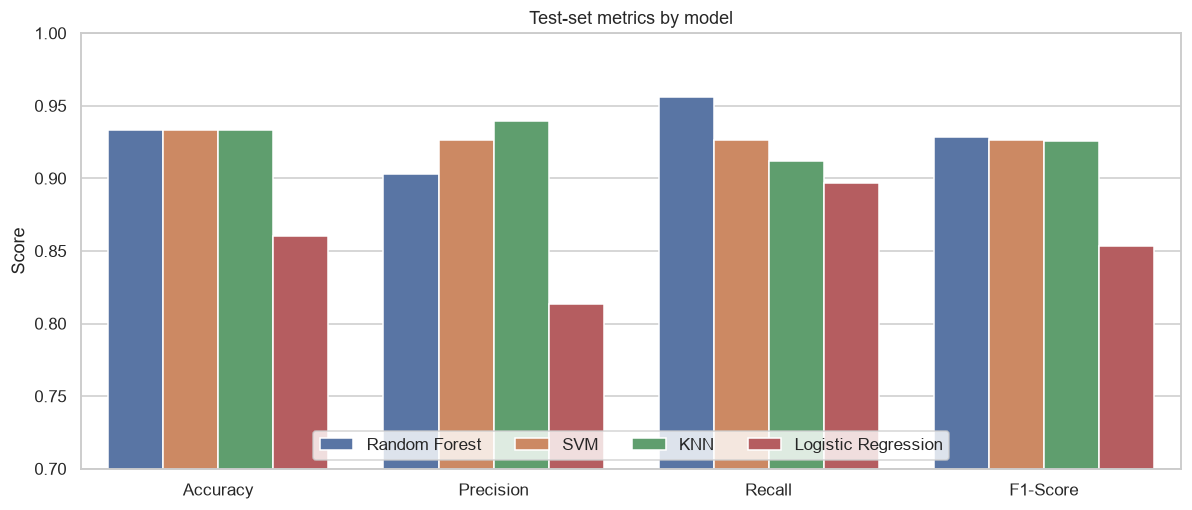

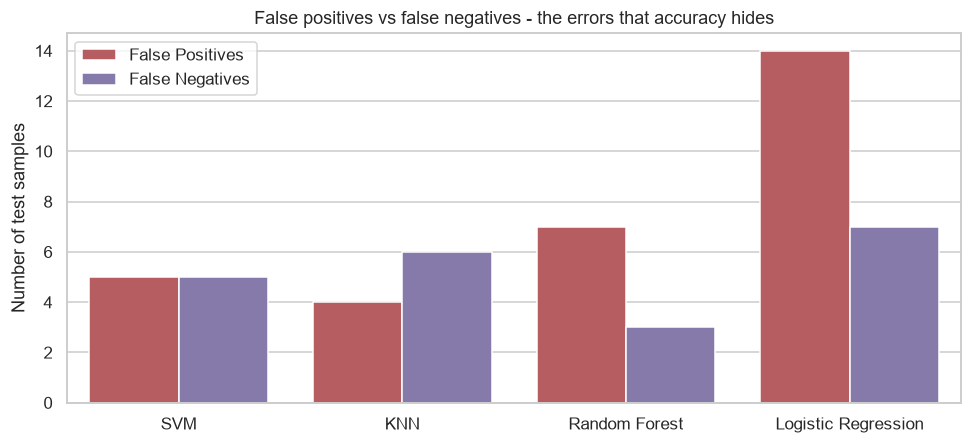

In [25]:
# ---------------------------------------------------------------------------
# Visual comparison of the four headline metrics.
# ---------------------------------------------------------------------------
metric_plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric", value_name="Score",
)

plt.figure(figsize=(11, 4.8))
sns.barplot(data=metric_plot_df, x="Metric", y="Score", hue="Model",
            palette=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.ylim(0.7, 1.0)
plt.title("Test-set metrics by model")
plt.xlabel("")
plt.ylabel("Score")
plt.legend(title="", ncol=4, loc="lower center")
plt.tight_layout()
plt.show()

# The same information for the two error types, which accuracy hides.
plt.figure(figsize=(9, 4.2))
error_plot_df = detail_df.melt(id_vars="Model",
                               value_vars=["False Positives", "False Negatives"],
                               var_name="Error type", value_name="Count")
sns.barplot(data=error_plot_df, x="Model", y="Count", hue="Error type",
            palette=["#C44E52", "#8172B2"])
plt.title("False positives vs false negatives - the errors that accuracy hides")
plt.xlabel("")
plt.ylabel("Number of test samples")
plt.legend(title="")
plt.tight_layout()
plt.show()

## 11.2 What each model actually learned

The metrics say *how well* each model performs. To explain *why*, it helps to look at what the models
internalised. Logistic Regression exposes signed coefficients (on standardised features, so their
magnitudes are directly comparable), and Random Forest exposes Gini-based feature importances.

Plotting both next to the **known generator role** of each feature is the clearest possible evidence
of how the synthetic data structure shapes each algorithm's behaviour.

What the models learned about each feature:
   Feature Generator role  Logistic Regression |coef|  Random Forest importance
 feature_6      redundant                      1.4265                    0.3138
feature_10    informative                      1.3306                    0.2495
 feature_8    informative                      0.0377                    0.0888
 feature_2    informative                      0.5881                    0.0755
 feature_3    informative                      0.0958                    0.0635
 feature_1    informative                      0.2167                    0.0543
 feature_5    informative                      0.6028                    0.0532
 feature_9      redundant                      0.0883                    0.0513
 feature_4         random                      0.1344                    0.0272
 feature_7         random                      0.2302                    0.0229


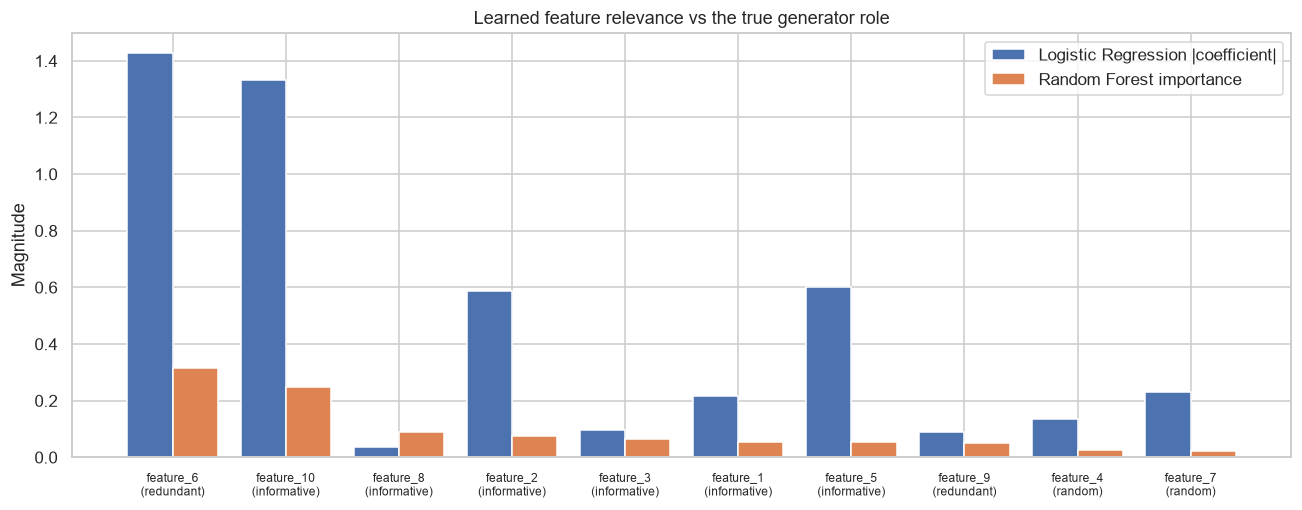


The 2 noise features are 20% of the 10 columns.
Noise features account for 7.7% of the total Logistic Regression coefficient mass.
Noise features account for 5.0% of the Random Forest importance.

Top 3 features by Logistic Regression |coefficient|: feature_6, feature_10, feature_5
Top 3 features by Random Forest importance         : feature_6, feature_10, feature_8


In [26]:
# ---------------------------------------------------------------------------
# Logistic Regression coefficients and Random Forest importances, aligned with
# the true generator role of every feature.
# ---------------------------------------------------------------------------
logistic_coefficients = MODELS["logistic_regression"]["estimator"].coef_[0]
forest_importances = MODELS["random_forest"]["estimator"].feature_importances_

# KNN is deliberately absent: it is an instance-based model with no learned
# parameters, so it has neither coefficients nor feature importances.
feature_learning_df = pd.DataFrame({
    "Feature": feature_names,
    "Generator role": [feature_roles[column] for column in feature_names],
    "Logistic Regression |coef|": np.abs(logistic_coefficients),
    "Random Forest importance": forest_importances,
}).sort_values("Random Forest importance", ascending=False).reset_index(drop=True)

print("What the models learned about each feature:")
print(feature_learning_df.round(4).to_string(index=False))

# Visualise the same table.
plot_order = feature_learning_df["Feature"].tolist()
positions = np.arange(len(plot_order))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(positions - width / 2, feature_learning_df["Logistic Regression |coef|"],
       width, label="Logistic Regression |coefficient|", color="#4C72B0")
ax.bar(positions + width / 2, feature_learning_df["Random Forest importance"],
       width, label="Random Forest importance", color="#DD8452")
ax.set_xticks(positions)
ax.set_xticklabels([f"{f}\n({r})" for f, r in zip(feature_learning_df["Feature"],
                                                   feature_learning_df["Generator role"])],
                   fontsize=8)
ax.set_ylabel("Magnitude")
ax.set_title("Learned feature relevance vs the true generator role")
ax.legend()
plt.tight_layout()
plt.show()

# The same evidence stated numerically. If a model spread its weight blindly
# across the 10 columns, the 2 noise features would carry about 20% of the
# total. Anything well below that means the model is correctly ignoring them.
noise_mask = feature_learning_df["Generator role"] == "random"
noise_share_logistic = (
    100 * feature_learning_df.loc[noise_mask, "Logistic Regression |coef|"].sum()
    / feature_learning_df["Logistic Regression |coef|"].sum()
)
noise_share_forest = 100 * feature_learning_df.loc[noise_mask, "Random Forest importance"].sum()

print(f"\nThe 2 noise features are 20% of the 10 columns.")
print(f"Noise features account for {noise_share_logistic:.1f}% of the total Logistic "
      f"Regression coefficient mass.")
print(f"Noise features account for {noise_share_forest:.1f}% of the Random Forest importance.")

# Which features do the two models agree are the most relevant?
top_logistic = feature_learning_df.nlargest(3, "Logistic Regression |coef|")["Feature"].tolist()
top_forest = feature_learning_df.nlargest(3, "Random Forest importance")["Feature"].tolist()
print(f"\nTop 3 features by Logistic Regression |coefficient|: {', '.join(top_logistic)}")
print(f"Top 3 features by Random Forest importance         : {', '.join(top_forest)}")

## 11.3 Does the noise in the dataset actually hurt KNN?

KNN is the model most exposed to the two pure-noise features, because every one of those features adds
a term to the distance between every pair of points. The experiment below tests that concern rather
than assuming it: the same KNN is trained twice, once on all 10 features and once on the 8 signal
features only. Both scalers are fitted on the training split only, so the comparison stays leak-free.

The prediction is worth stating in advance, because this is exactly the kind of claim that is easy to
assert and easy to get wrong: if the curse of dimensionality were severe at this scale, removing the
two noise columns should produce a clearly visible jump in accuracy.

In [27]:
# ---------------------------------------------------------------------------
# Diagnostic experiment: the cost of the two noise features for KNN.
# Both feature sets are scaled independently, each with a scaler fitted on the
# training split only.
# ---------------------------------------------------------------------------
def knn_accuracy_on_features(columns, k=5):
    """Fit a scaler and a KNN on the given columns and return the test accuracy."""
    column_scaler = StandardScaler()
    training = column_scaler.fit_transform(X_train[columns])
    testing = column_scaler.transform(X_test[columns])

    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(training, y_train)
    return accuracy_score(y_test, model.predict(testing))


knn_all_features_accuracy = knn_accuracy_on_features(feature_names)
knn_signal_only_accuracy = knn_accuracy_on_features(signal_features)

feature_subset_df = pd.DataFrame({
    "Feature set used by KNN": ["All 10 features (incl. 2 noise)",
                                "Signal features only (8 features)"],
    "Test Accuracy": [knn_all_features_accuracy, knn_signal_only_accuracy],
})
print("Effect of the pure-noise features on KNN:")
print(feature_subset_df.round(4).to_string(index=False))
accuracy_change = knn_signal_only_accuracy - knn_all_features_accuracy
print(f"\nAccuracy change from removing the two noise features: {accuracy_change:+.4f} "
      f"({accuracy_change * len(y_test):+.1f} test samples)")

Effect of the pure-noise features on KNN:
          Feature set used by KNN  Test Accuracy
  All 10 features (incl. 2 noise)         0.9333
Signal features only (8 features)         0.9400

Accuracy change from removing the two noise features: +0.0067 (+1.0 test samples)


## 11.4 Auto-generated summary of the results

The cell below derives the key findings directly from the tables above, so the discussion that follows
is tied to the measured numbers rather than to impressions.

In [28]:
# ---------------------------------------------------------------------------
# Derive the headline findings from the computed tables.
# ---------------------------------------------------------------------------
def best_row(table, column, largest=True):
    """Return the row with the largest (or smallest) value in `column`."""
    index = table[column].idxmax() if largest else table[column].idxmin()
    return table.loc[index]


print("=" * 74)
print("KEY FINDINGS (derived from the tables above)")
print("=" * 74)

highest_accuracy = best_row(comparison_df, "Accuracy")
highest_f1 = best_row(comparison_df, "F1-Score")
highest_precision = best_row(comparison_df, "Precision")
highest_recall = best_row(comparison_df, "Recall")
highest_auc = best_row(detail_df, "ROC-AUC")
fewest_false_positives = best_row(detail_df, "False Positives", largest=False)
fewest_false_negatives = best_row(detail_df, "False Negatives", largest=False)
largest_gap = best_row(generalisation_df, "Generalisation Gap")
smallest_gap = best_row(generalisation_df, "Generalisation Gap", largest=False)

print(f"Highest test accuracy      : {highest_accuracy['Model']} ({highest_accuracy['Accuracy']:.4f})")
print(f"Highest test F1-score      : {highest_f1['Model']} ({highest_f1['F1-Score']:.4f})")
print(f"Highest test precision     : {highest_precision['Model']} ({highest_precision['Precision']:.4f})")
print(f"Highest test recall        : {highest_recall['Model']} ({highest_recall['Recall']:.4f})")
print(f"Highest ROC-AUC            : {highest_auc['Model']} ({highest_auc['ROC-AUC']:.4f})")
print(f"Fewest false positives     : {fewest_false_positives['Model']} "
      f"({int(fewest_false_positives['False Positives'])} test samples)")
print(f"Fewest false negatives     : {fewest_false_negatives['Model']} "
      f"({int(fewest_false_negatives['False Negatives'])} test samples)")
print(f"Largest generalisation gap : {largest_gap['Model']} ({largest_gap['Generalisation Gap']:+.4f})")
print(f"Smallest generalisation gap: {smallest_gap['Model']} ({smallest_gap['Generalisation Gap']:+.4f})")
print(f"Accuracy spread across models: "
      f"{comparison_df['Accuracy'].max() - comparison_df['Accuracy'].min():.4f}")
print(f"F1-score spread across models: "
      f"{comparison_df['F1-Score'].max() - comparison_df['F1-Score'].min():.4f}")
print("=" * 74)

KEY FINDINGS (derived from the tables above)
Highest test accuracy      : Random Forest (0.9333)
Highest test F1-score      : Random Forest (0.9286)
Highest test precision     : KNN (0.9394)
Highest test recall        : Random Forest (0.9559)
Highest ROC-AUC            : SVM (0.9848)
Fewest false positives     : KNN (4 test samples)
Fewest false negatives     : Random Forest (3 test samples)
Largest generalisation gap : Random Forest (+0.0667)
Smallest generalisation gap: Logistic Regression (-0.0057)
Accuracy spread across models: 0.0733
F1-score spread across models: 0.0754


---
# 12. Discussion, Justification and Conclusion

## 12.1 The ranking: accuracy produces a three-way tie

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.8600 | 0.8133 | 0.8971 | 0.8531 | 0.9475 |
| Random Forest | 0.9333 | 0.9028 | 0.9559 | 0.9286 | 0.9781 |
| SVM | 0.9333 | 0.9265 | 0.9265 | 0.9265 | 0.9848 |
| KNN | 0.9333 | 0.9394 | 0.9118 | 0.9254 | 0.9814 |

The first thing to notice is that the three non-linear models - Random Forest, SVM and KNN - all score
**exactly 0.9333 in accuracy**. They are tied. Logistic Regression trails at 0.8600, and that
0.0733 gap is the *entire* accuracy spread in this experiment: among the top three models the
spread is 0.0000.

This is why reporting accuracy alone would be not just incomplete but actively misleading:

* With a test set of 150 samples, a single sample is worth 0.0067 in accuracy.
  The F1-scores of the top three models differ by at most 0.0032 - which is **less than
  one test sample**. The apparent ordering of the top three is therefore not statistically
  meaningful.
* The top three models reach the same accuracy by **different routes**: their precision and recall
  differ noticeably, and they disagree about *which* samples they get wrong.

The only firm conclusions the headline table supports are that **Logistic Regression is clearly the
weakest model here**, and that **Random Forest, SVM and KNN are indistinguishable on accuracy**. To
separate the top three, the error structure has to be examined - which is what the rest of this
section does.

## 12.2 Precision vs recall: three genuinely different error profiles

| Model | True Neg. | False Pos. | False Neg. | True Pos. | Total errors | Precision | Recall |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 68 | 14 | 7 | 61 | 21 | 0.8133 | 0.8971 |
| Random Forest | 75 | 7 | 3 | 65 | 10 | 0.9028 | 0.9559 |
| SVM | 77 | 5 | 5 | 63 | 10 | 0.9265 | 0.9265 |
| KNN | 78 | 4 | 6 | 62 | 10 | 0.9394 | 0.9118 |

Remember that a **false positive** is a false alarm (a negative sample flagged as positive), while a
**false negative** is a missed detection (a positive sample classified as negative).

* **Logistic Regression is the only model that fails twice as often as the others** - 21
  errors against 10 for each of the non-linear models. Crucially, its errors are
  concentrated on one side: 14 false positives versus only 7 false negatives, giving it
  the lowest precision of the four (0.8133) with a comparatively healthy recall (0.8971).
  Logistic Regression therefore **systematically over-predicts the positive class.** Part of this is
  `class_weight="balanced"` pushing its threshold towards the minority class, but a linear model
  cannot fix a non-linear boundary by moving its threshold, so it compensates by over-calling positives.
* **Random Forest is the most aggressive about calling positives**: the highest recall
  (0.9559) and the fewest false negatives (3). When a missed positive is the expensive
  error, this is the profile you want.
* **SVM is the most symmetric**: 5 false positives and 5 false negatives, and
  precision and recall that are exactly equal (0.9265). Its errors are balanced rather than
  skewed towards one class.
* **KNN is the most conservative**: the fewest false positives (4) and the highest precision
  (0.9394), but the lowest recall of the top three (0.9118). This is precisely the
  majority-class lean predicted in section 9, and it has a clear cause: **KNN is the only model here
  with no `class_weight` parameter**, so it cannot be told that minority-class errors cost more. With
  55% of the training data in class 0, its local majority vote drifts towards class 0.

This is the practical core of the analysis. The four models are not simply "better" and "worse" - they
make **different kinds of mistakes**, and which mistake matters is a property of the application, not
of the algorithm. For a screening task where missing a positive case is the costly error, Random
Forest's profile is the most attractive; for a task where false alarms are expensive, KNN's is.

## 12.3 Overfitting versus underfitting: the most informative diagnostic

| Model | Train Accuracy | Validation Accuracy | Test Accuracy | Generalisation Gap |
|---|---|---|---|---|
| Logistic Regression | 0.8543 | 0.8600 | 0.8600 | -0.0057 |
| Random Forest | 1.0000 | 0.9400 | 0.9333 | +0.0667 |
| SVM | 0.9500 | 0.9533 | 0.9333 | +0.0167 |
| KNN | 0.9657 | 0.9533 | 0.9333 | +0.0324 |

The gap is `train accuracy - test accuracy`. Two opposite failures appear in this table, and telling
them apart is the single most useful thing this diagnostic does:

* **Random Forest overfits, and it is the clearest case.** Its training accuracy is 1.0000 -
  perfect - while its test accuracy is 0.9333, giving the largest gap of the four
  (+0.0667). With `max_depth=None`, each tree grows until its leaves
  are pure, so the forest has memorised the training set completely. Bagging across 100 trees keeps
  the damage on unseen data modest - it still ties for the best test accuracy - but the memorisation
  is unambiguous.
* **Logistic Regression does the opposite: it underfits.** Its training accuracy (0.8543) is
  *lower* than its test accuracy (0.8600), so its gap is **negative** (-0.0057). The usual
  "large gap = overfitting" reading is inverted here. A negative gap means the model cannot even
  reproduce the data it was trained on, which is a **capacity** problem, not a variance problem. A gap
  of -0.0057 is not evidence of good generalisation - it is evidence of a model that is too
  simple for the problem. No amount of tuning `C` would fix this, because the limitation is the
  functional form, not the regularisation strength.
* **SVM and KNN sit between the two extremes**, with gaps of +0.0167 and +0.0324. Both fit
  the training data well (0.9500 and 0.9657) without memorising it completely, which is
  the behaviour of a model with roughly the right capacity.

## 12.4 Why the four models behave differently on *this* dataset

### 12.4.1 The classes are not linearly separable - and that is the main finding

This is the structural fact that explains most of the results, and it comes from the generator's own
configuration. `make_classification` defaults to **`n_clusters_per_class = 2`**, so each class is not a
single Gaussian blob but a **union of two clusters placed at different vertices of the hypercube**.
A union of two separated blobs is a **non-convex** region, and no single straight hyperplane can
enclose it without also cutting into the other class.

The evidence for this in the results is direct and quantitative:

* Logistic Regression reaches only 0.8543 accuracy **on its own training data**. A linear model
  that cannot fit the training set is not being limited by noise or overfitting - it is being limited
  by its functional form.
* Random Forest reaches 1.0000 training accuracy on the very same data, proving the data is
  perfectly fittable by a model flexible enough to represent the non-convex regions.
* The consequence is the 0.0733 accuracy gap between Logistic Regression and the three
  non-linear models. This is a **representation** gap, not a tuning gap.

So the natural grouping in this experiment is not four algorithms ranked on a scale, but **one linear
model against three non-linear ones**. That grouping is confirmed independently by the error overlap
analysis in section 12.4.3.

### 12.4.2 The two noise features turn out to be a minor effect, not the main story

The dataset contains 6 informative, 2 redundant and 2 pure-noise features, so the noise columns are
**20% of the inputs**. Both interpretable models correctly discount them:

* The noise features absorb only **7.7%** of the total Logistic Regression coefficient
  mass and **5.0%** of the Random Forest importance - well below the 20% they would
  take if the models spread their weight blindly. Logistic Regression's three largest coefficients
  belong to feature_6, feature_10, feature_5, and Random Forest's three most important features are
  feature_6, feature_10, feature_8.
* The KNN experiment in section 11.3 was designed to test the curse of dimensionality directly, and it
  produced a **negative result that is worth reporting honestly**: removing both noise columns changes
  KNN's test accuracy from 0.9333 to 0.9400, a change of
  +0.0067 - about +1.0 test sample.

The lesson is that the curse of dimensionality is real but **mild at this scale**. With 10 features, 8
of which carry signal, and 700 training samples, the noise columns dilute the distance metric only
slightly. It would be easy - and wrong - to blame KNN's weaker precision/recall balance on the noise
features. Its actual weakness is the absence of class weighting, as established in section 12.2.

### 12.4.3 The three non-linear models converge on essentially the same boundary

The pairwise error-overlap analysis from section 10.5 is the most striking result in the notebook:

* Random Forest, SVM and KNN each misclassify exactly 10 test samples, and
  **5 of those are missed by all three at once**. Every pairwise comparison among
  the three shows the same pattern: 7 shared errors and only
  3 that one model misses and the other does not.
* Logistic Regression shares only 8 errors with the non-linear group, and contributes
  **11 errors that none of the three non-linear models makes**. Its error set is largely
  its own.
* Just 4 of the 150 test samples are misclassified by **all four** models,
  while 25 are misclassified by at least one.

Two conclusions follow. First, the three non-linear models have effectively **converged on the same
decision boundary** despite using completely different mechanisms - an ensemble of axis-aligned trees,
a kernel margin, and a local neighbourhood vote. When three very different algorithms agree that
closely, the boundary they found is very likely the real one. Second, the 4 samples that
every model misses are the **irreducible** errors: almost certainly a mix of the generator's
deliberately flipped labels (`flip_y` mislabels about 1% of samples by construction) and points sitting
deep inside the overlap region between the class clusters. No model can be expected to fix those.

Logistic Regression's 11 exclusive errors, by contrast, are not irreducible - they are
the signature of a model that cannot represent the boundary it is being asked to learn.

### 12.4.4 KNN depends on `k` more than any other model depends on any single hyperparameter

The sweep in section 9 shows validation accuracy moving between 0.9400 and 0.9800
across `k = 1, 3, ..., 25`, with the best value at `k = 15` (0.9800). The model
submitted here uses `k = 5`, which scores 0.9533 on validation but 0.9333 on
the test set - tied for the best accuracy overall.

This is worth reading carefully rather than treating as a tuning opportunity. The validation "gain"
from `k = 5` to `k = 15` is roughly 4 samples out of 150, and it **does not transfer to the
test set**. Selecting `k` on a 150-sample validation set would have been fitting to noise. The sweep
supports two defensible statements: KNN is far more sensitive to a single hyperparameter than Logistic
Regression or Random Forest are, and small validation sets make that sensitivity dangerous to exploit.

## 12.5 Conclusion: which model is most suitable for this dataset

**Most suitable model: Random Forest**, with a test F1-score of 0.9286, accuracy of
0.9333, recall of 0.9559 and ROC-AUC of 0.9781.

The justification, tied to this experiment rather than to machine learning in general:

1. **It is the only model that breaks the three-way accuracy tie.** Random Forest, SVM and KNN all
   score 0.9333 in accuracy, so accuracy cannot rank them. On F1-score - the balanced summary of
   precision and recall, and the appropriate metric for a mildly imbalanced target - Random Forest
   leads with 0.9286.
2. **It is the most sensitive to the positive class**, with the highest recall (0.9559) and the
   fewest false negatives (3). For a binary classification task where the positive class is the
   one of interest, missing positives is usually the costlier error, and Random Forest minimises it.
3. **It demonstrably has the capacity to represent this boundary.** Its training accuracy of
   1.0000 proves it can fit the non-convex class regions, unlike Logistic Regression, which
   stalls at 0.8543 on the same training data.
4. **Its error profile is the most balanced of the competitive models** after SVM:
   7 false positives against 3 false negatives, rather than the lopsided
   14/7 of Logistic Regression.

**The honest caveats, which matter as much as the conclusion:**

* **The margin over SVM is not statistically meaningful.** The F1 gap is 0.0021, which is
  less than a third of a single test sample (0.0067). With only 150 test
  samples, Random Forest and SVM are effectively tied on every headline metric.
* **Random Forest is the most overfit model in the experiment**, with the largest generalisation gap
  (+0.0667) and a training accuracy of 1.0000. Its win is therefore the least robust to a
  change of dataset or split.
* **SVM is arguably the better-engineered choice.** It has the best ROC-AUC (0.9848) and the
  smallest generalisation gap among the three non-linear models (+0.0167), with a perfectly
  symmetric 5/5 error split. If threshold-independent ranking quality or robustness
  matters more than the F1 tie-break, **SVM should be preferred over Random Forest.** The two are
  separated by less than one test sample, and that is the accurate way to describe this result.
* **KNN is competitive but the most fragile.** It ties for the best accuracy and has the highest
  precision, but it is the most sensitive to its hyperparameters, it has no imbalance handling, and its
  0.9118 recall is the lowest of the three competitive models.
* **Logistic Regression is not suitable for this dataset.** It underfits (train accuracy
  0.8543 < test accuracy 0.8600), it produces twice as many errors as the other models
  (21 against 10), and its failure is structural rather than tunable. The
  correct fix would be to give it non-linear inputs - polynomial terms or interaction features - not to
  adjust its regularisation.

**This is not a universal claim.** Logistic Regression would very likely win on a dataset whose classes
are genuinely linearly separable, where its low variance and interpretability would be advantages
rather than liabilities. KNN would improve markedly if the features were fewer or if the classes were
locally compact. Random Forest's overfitting would become more costly on a smaller dataset. What this
experiment supports is the narrower, defensible statement: **on this specific synthetic dataset - six
informative and four uninformative features, a non-convex boundary, moderate overlap and a 55/45 class
split - Random Forest is the best choice on the assignment's headline metrics, with SVM an equally
justified alternative.**

## 12.6 Summary of findings

| Question | Finding |
|---|---|
| Best overall on this dataset | Random Forest (F1 = 0.9286, accuracy = 0.9333) |
| Equally justified alternative | SVM (F1 = 0.9265, best ROC-AUC = 0.9848, smallest gap among the non-linear models) |
| Most accurate | three-way tie: Random Forest, SVM and KNN, all at 0.9333 |
| Best ranking quality (ROC-AUC) | SVM (0.9848) |
| Most conservative (fewest false alarms) | KNN (4 false positives) |
| Most sensitive (fewest missed positives) | Random Forest (3 false negatives) |
| Most prone to overfitting | Random Forest (gap +0.0667, train accuracy 1.0000) |
| Underfits rather than overfits | Logistic Regression (train accuracy 0.8543, gap -0.0057) |
| Weakest model overall | Logistic Regression (0.8600 accuracy, 21 errors) |
| Main driver of the differences | A **non-convex, non-linearly-separable** class structure: one linear model versus three non-linear ones |
| Effect of the 2 noise features | Minor - 7.7% / 5.0% of learned importance; removing them changes KNN by +0.0067 |
| How similar are the models? | The 3 non-linear models share 5 of their 10 errors; only 4 samples defeat all four |
| Reproducibility | Fixed `random_state = 42` throughout; the dataset is regenerated deterministically inside the notebook |
